# Assignment 1

## Smoothing filters 

In [2]:
import numpy as np
import matplotlib.pyplot as plt


ecg_data = np.load("signal_sources/ECG_template.npz")

sampling_frequency = 500  # Hz
amplitude_units = "mV"

print("Available arrays:", ecg_data.files)

Available arrays: ['ECG_template']


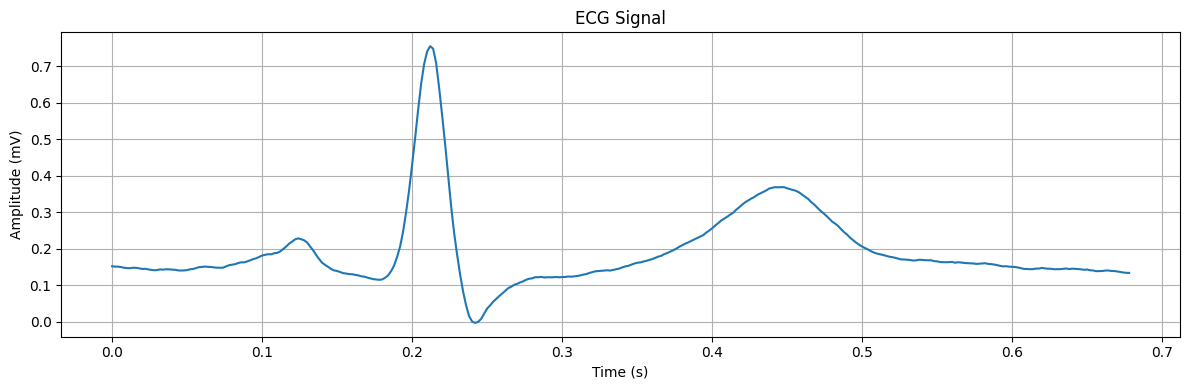

In [ ]:


ecg_signal = np.asarray(ecg_data["ECG_template"]).squeeze()
time = np.arange(ecg_signal.size) / sampling_frequency

plt.figure(figsize=(12, 4))
plt.plot(time, ecg_signal)
plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("ECG Signal")
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
target_snr_db = 5

signal_power = np.mean(ecg_signal**2)
target_noise_power = signal_power / (10 ** (target_snr_db / 10))

noise = np.random.randn(ecg_signal.size)
noise *= np.sqrt(target_noise_power / np.mean(noise**2))

nECG = ecg_signal + noise

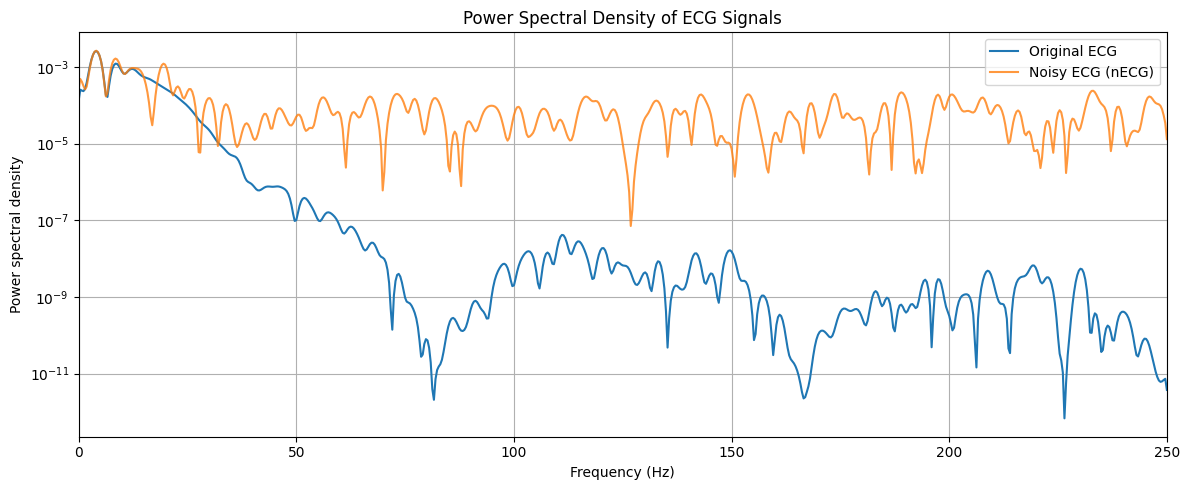

In [5]:
from scipy.signal import periodogram

nfft = 4 * len(ecg_signal)

frequencies, psd_ecg = periodogram(
    ecg_signal,
    fs=sampling_frequency,
    window="hann",
    nfft=nfft
)

_, psd_nECG = periodogram(
    nECG,
    fs=sampling_frequency,
    window="hann",
    nfft=nfft
)

plt.figure(figsize=(12, 5))
plt.semilogy(frequencies, psd_ecg, label="Original ECG")
plt.semilogy(frequencies, psd_nECG, label="Noisy ECG (nECG)", alpha=0.8)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("Power Spectral Density of ECG Signals")
plt.xlim(0, sampling_frequency / 2)
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### MA(3) filter implementation with a custom function

In [6]:
def ma3_filter(signal):
    """Apply a causal 3-point moving-average filter."""
    signal = np.asarray(signal)
    filtered = np.zeros_like(signal, dtype=float)

    for n in range(signal.size):
        start = max(0, n - 2)
        filtered[n] = np.mean(signal[start:n + 1])

    return filtered


ma3ECG_1 = ma3_filter(nECG)

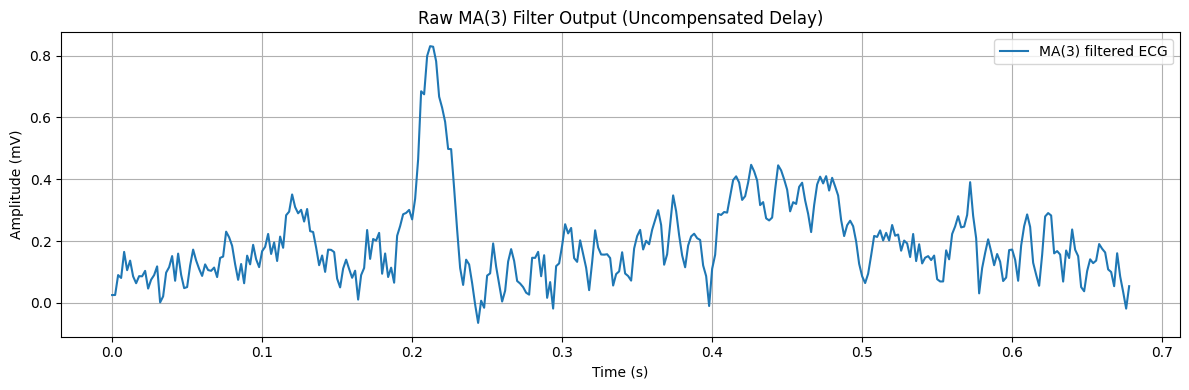

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(time, ma3ECG_1, label="MA(3) filtered ECG")
plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Raw MA(3) Filter Output (Uncompensated Delay)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

For an MA($N$) filter, the group delay is given by

$$
\tau_g = \frac{N - 1}{2}
$$

where $N$ is the number of filter coefficients. For the MA(3) filter:

$$
\tau_g = \frac{3 - 1}{2} = 1 \text{ sample}
$$

With a sampling frequency of $500$ Hz, the corresponding time delay is

$$
\tau_g = \frac{1}{500} = 0.002 \text{ s}
$$

Therefore, the filtered ECG signal is delayed by one sample, or 2 ms. This delay should be compensated when comparing the filtered signal with the original ECG signal.

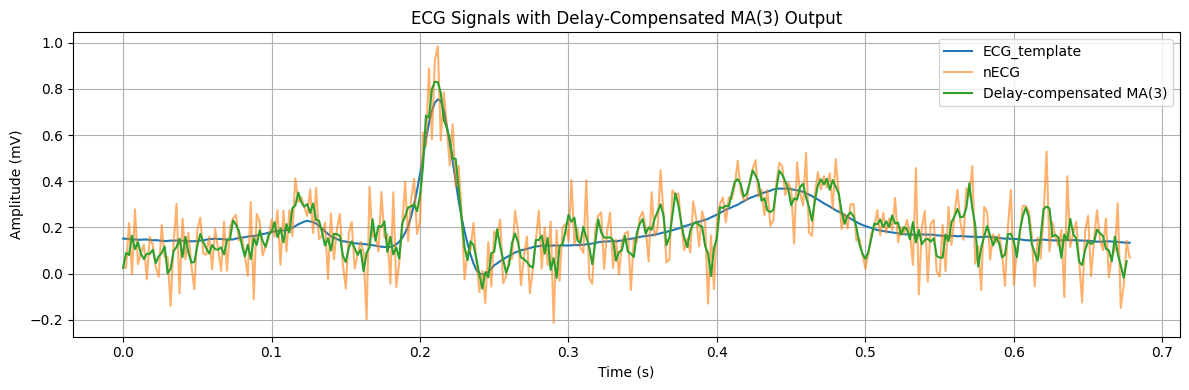

In [10]:
plt.figure(figsize=(12, 4))

plt.plot(time, ecg_signal, label="ECG_template", linewidth=1.5)
plt.plot(time, nECG, label="nECG", alpha=0.6)
plt.plot(time[:-1], ma3ECG_1[1:], label="Delay-compensated MA(3)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("ECG Signals with Delay-Compensated MA(3) Output")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

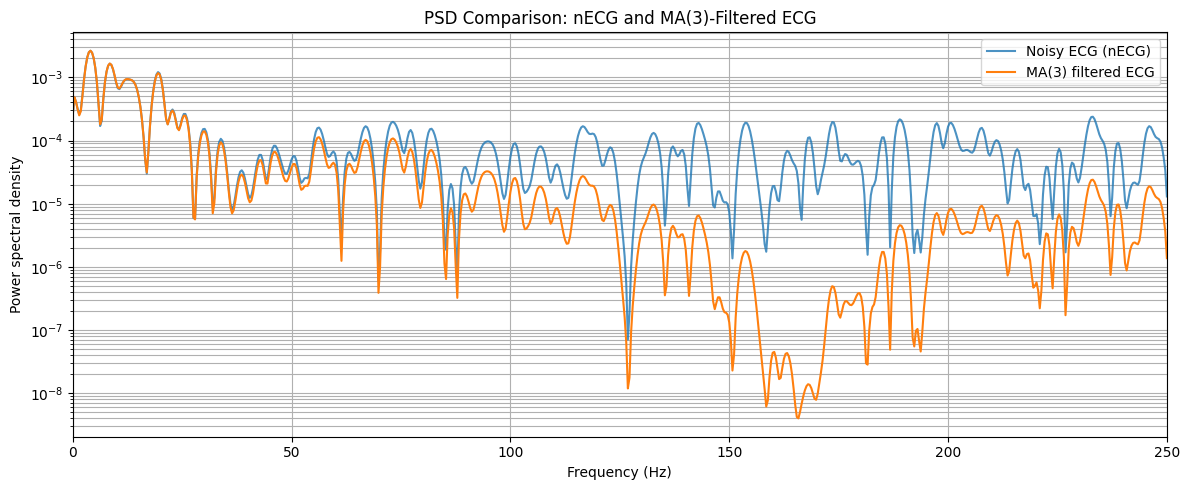

In [11]:
frequencies_ma3, psd_ma3ECG_1 = periodogram(
    ma3ECG_1,
    fs=sampling_frequency,
    window="hann",
    nfft=nfft
)

plt.figure(figsize=(12, 5))
plt.semilogy(frequencies, psd_nECG, label="Noisy ECG (nECG)", alpha=0.8)
plt.semilogy(
    frequencies_ma3,
    psd_ma3ECG_1,
    label="MA(3) filtered ECG",
    linewidth=1.5
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("PSD Comparison: nECG and MA(3)-Filtered ECG")
plt.xlim(0, sampling_frequency / 2)
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

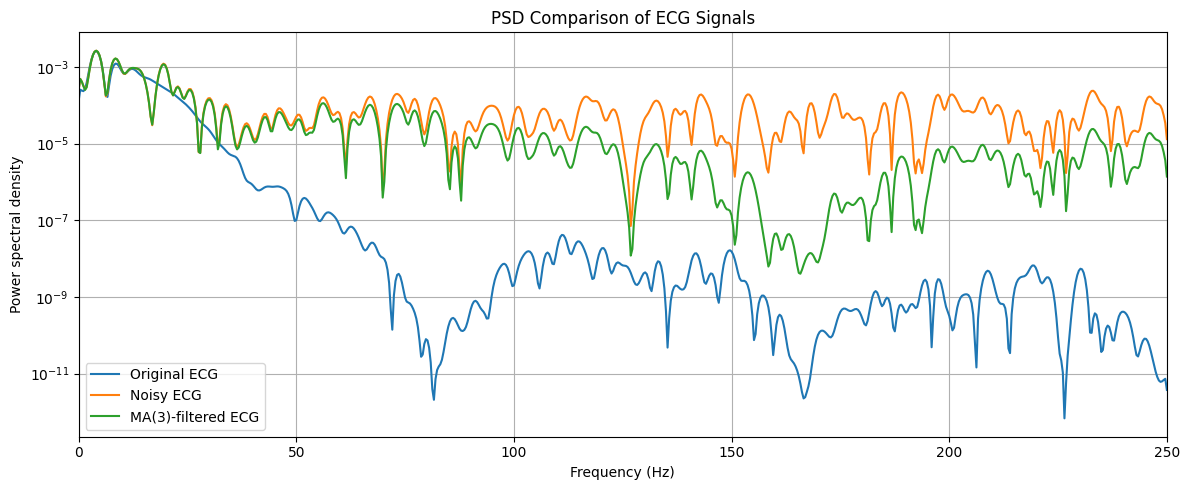

In [15]:
plt.figure(figsize=(12, 5))

plt.semilogy(frequencies, psd_ecg, label="Original ECG")
plt.semilogy(frequencies, psd_nECG, label="Noisy ECG")
plt.semilogy(frequencies_ma3, psd_ma3ECG_1, label="MA(3)-filtered ECG")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("PSD Comparison of ECG Signals")
plt.xlim(0, sampling_frequency / 2)
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### MA(3) filter implementation with a built-in function

In [17]:
from scipy.signal import lfilter

b = np.ones(3) / 3
a = np.array([1.0])

ma3ECG_lfilter = lfilter(b, a, nECG)

# Compensate for the one-sample group delay
ma3ECG_2 = ma3ECG_lfilter[1:]

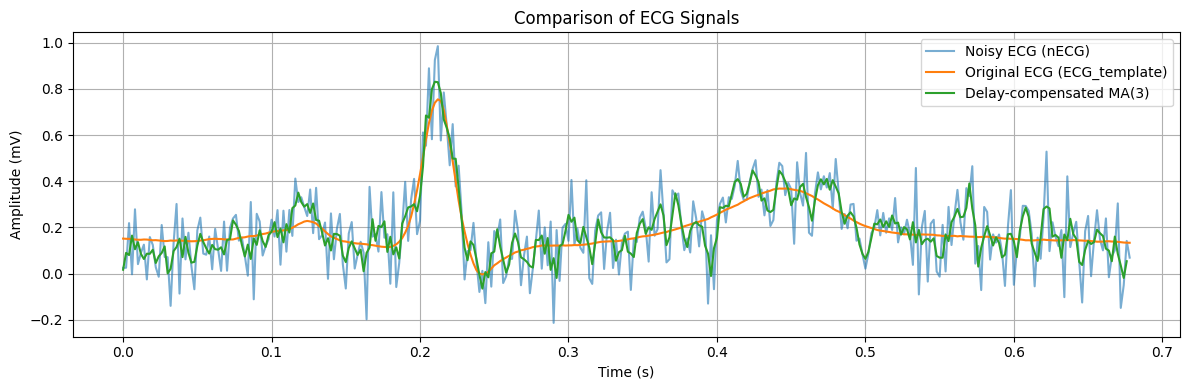

In [18]:
plt.figure(figsize=(12, 4))

plt.plot(time, nECG, label="Noisy ECG (nECG)", alpha=0.6)
plt.plot(time, ecg_signal, label="Original ECG (ECG_template)", linewidth=1.5)
plt.plot(
    time[:-1],
    ma3ECG_2,
    label="Delay-compensated MA(3)",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of ECG Signals")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

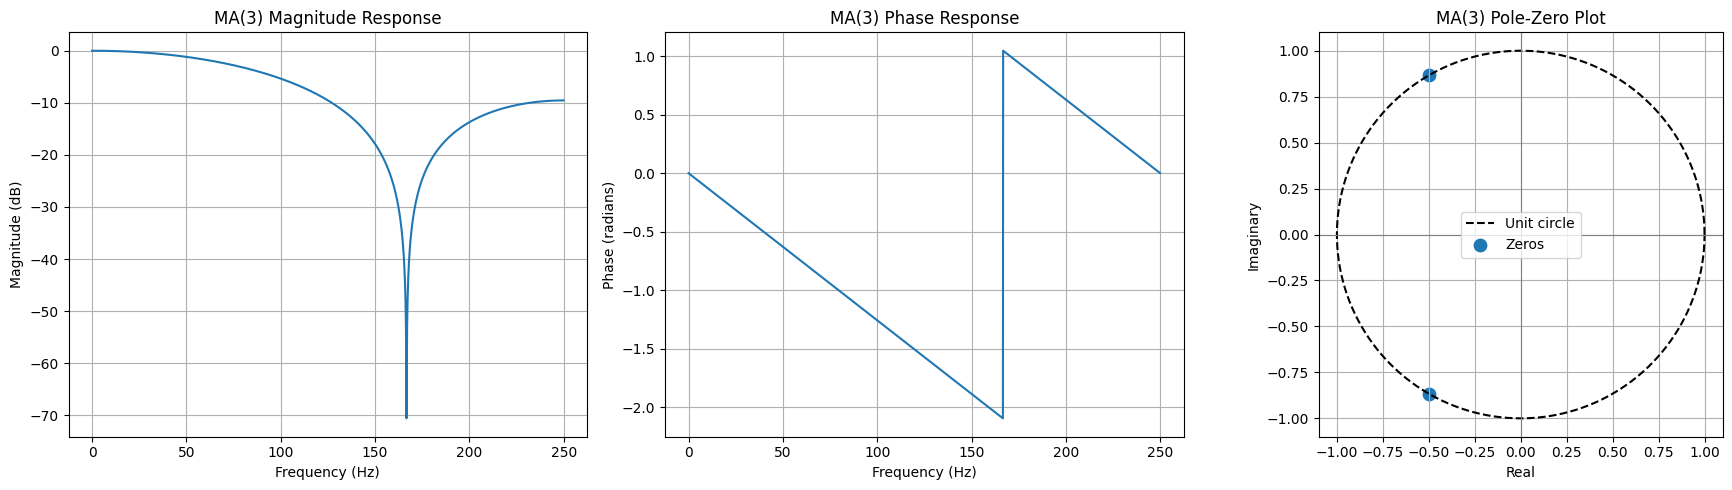

Zeros: [-0.5+0.8660254j -0.5-0.8660254j]
Poles: []


In [19]:
from scipy.signal import freqz

# Frequency and phase response
w, h = freqz(b, a, worN=2048, fs=sampling_frequency)

magnitude_db = 20 * np.log10(np.maximum(np.abs(h), np.finfo(float).eps))
phase = np.unwrap(np.angle(h))

# Zeros and poles
zeros = np.roots(b)
poles = np.roots(a)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Magnitude response
axes[0].plot(w, magnitude_db)
axes[0].set_title("MA(3) Magnitude Response")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude (dB)")
axes[0].grid(True)

# Phase response
axes[1].plot(w, phase)
axes[1].set_title("MA(3) Phase Response")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Phase (radians)")
axes[1].grid(True)

# Pole-zero plot
theta = np.linspace(0, 2 * np.pi, 500)
axes[2].plot(np.cos(theta), np.sin(theta), "k--", label="Unit circle")
axes[2].scatter(zeros.real, zeros.imag, marker="o", s=80, label="Zeros")

if poles.size:
    axes[2].scatter(
        poles.real,
        poles.imag,
        marker="x",
        s=80,
        linewidths=2,
        label="Poles"
    )

axes[2].axhline(0, color="gray", linewidth=0.8)
axes[2].axvline(0, color="gray", linewidth=0.8)
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title("MA(3) Pole-Zero Plot")
axes[2].set_xlabel("Real")
axes[2].set_ylabel("Imaginary")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

print("Zeros:", zeros)
print("Poles:", poles)

### MA(10) filter implementation with a built-in function

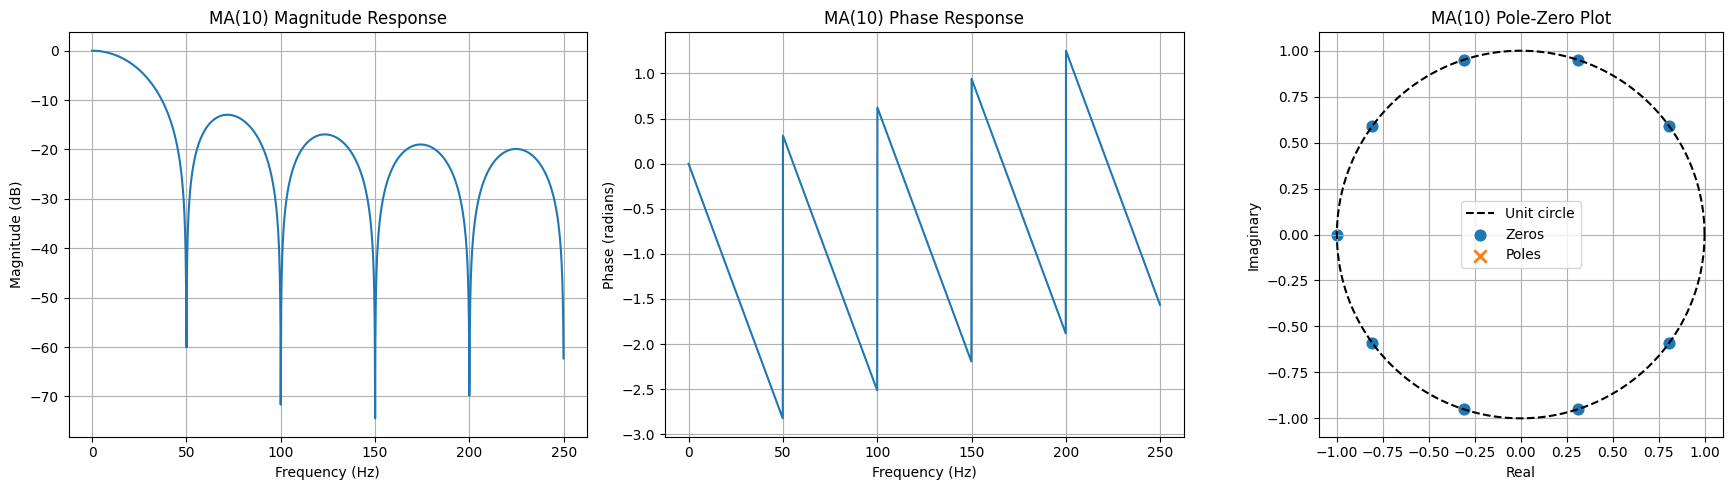

Zeros: [ 0.80901699+0.58778525j  0.80901699-0.58778525j  0.30901699+0.95105652j
  0.30901699-0.95105652j -1.        +0.j         -0.80901699+0.58778525j
 -0.80901699-0.58778525j -0.30901699+0.95105652j -0.30901699-0.95105652j]
Poles: []


In [21]:
# MA(10) filter using scipy.signal.lfilter
N = 10
b10 = np.ones(N) / N
a10 = np.array([1.0])

# Frequency and phase response
w10, h10 = freqz(b10, a10, worN=2048, fs=sampling_frequency)

magnitude_ma10_db = 20 * np.log10(
    np.maximum(np.abs(h10), np.finfo(float).eps)
)
phase_ma10 = np.unwrap(np.angle(h10))

# Zeros and poles
zeros_ma10 = np.roots(b10)
poles_ma10 = np.roots(a10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(w10, magnitude_ma10_db)
axes[0].set_title("MA(10) Magnitude Response")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude (dB)")
axes[0].grid(True)

axes[1].plot(w10, phase_ma10)
axes[1].set_title("MA(10) Phase Response")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Phase (radians)")
axes[1].grid(True)

axes[2].plot(np.cos(theta), np.sin(theta), "k--", label="Unit circle")
axes[2].scatter(
    zeros_ma10.real,
    zeros_ma10.imag,
    marker="o",
    s=60,
    label="Zeros"
)
axes[2].scatter(
    poles_ma10.real,
    poles_ma10.imag,
    marker="x",
    s=80,
    linewidths=2,
    label="Poles"
)
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title("MA(10) Pole-Zero Plot")
axes[2].set_xlabel("Real")
axes[2].set_ylabel("Imaginary")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

print("Zeros:", zeros_ma10)
print("Poles:", poles_ma10)



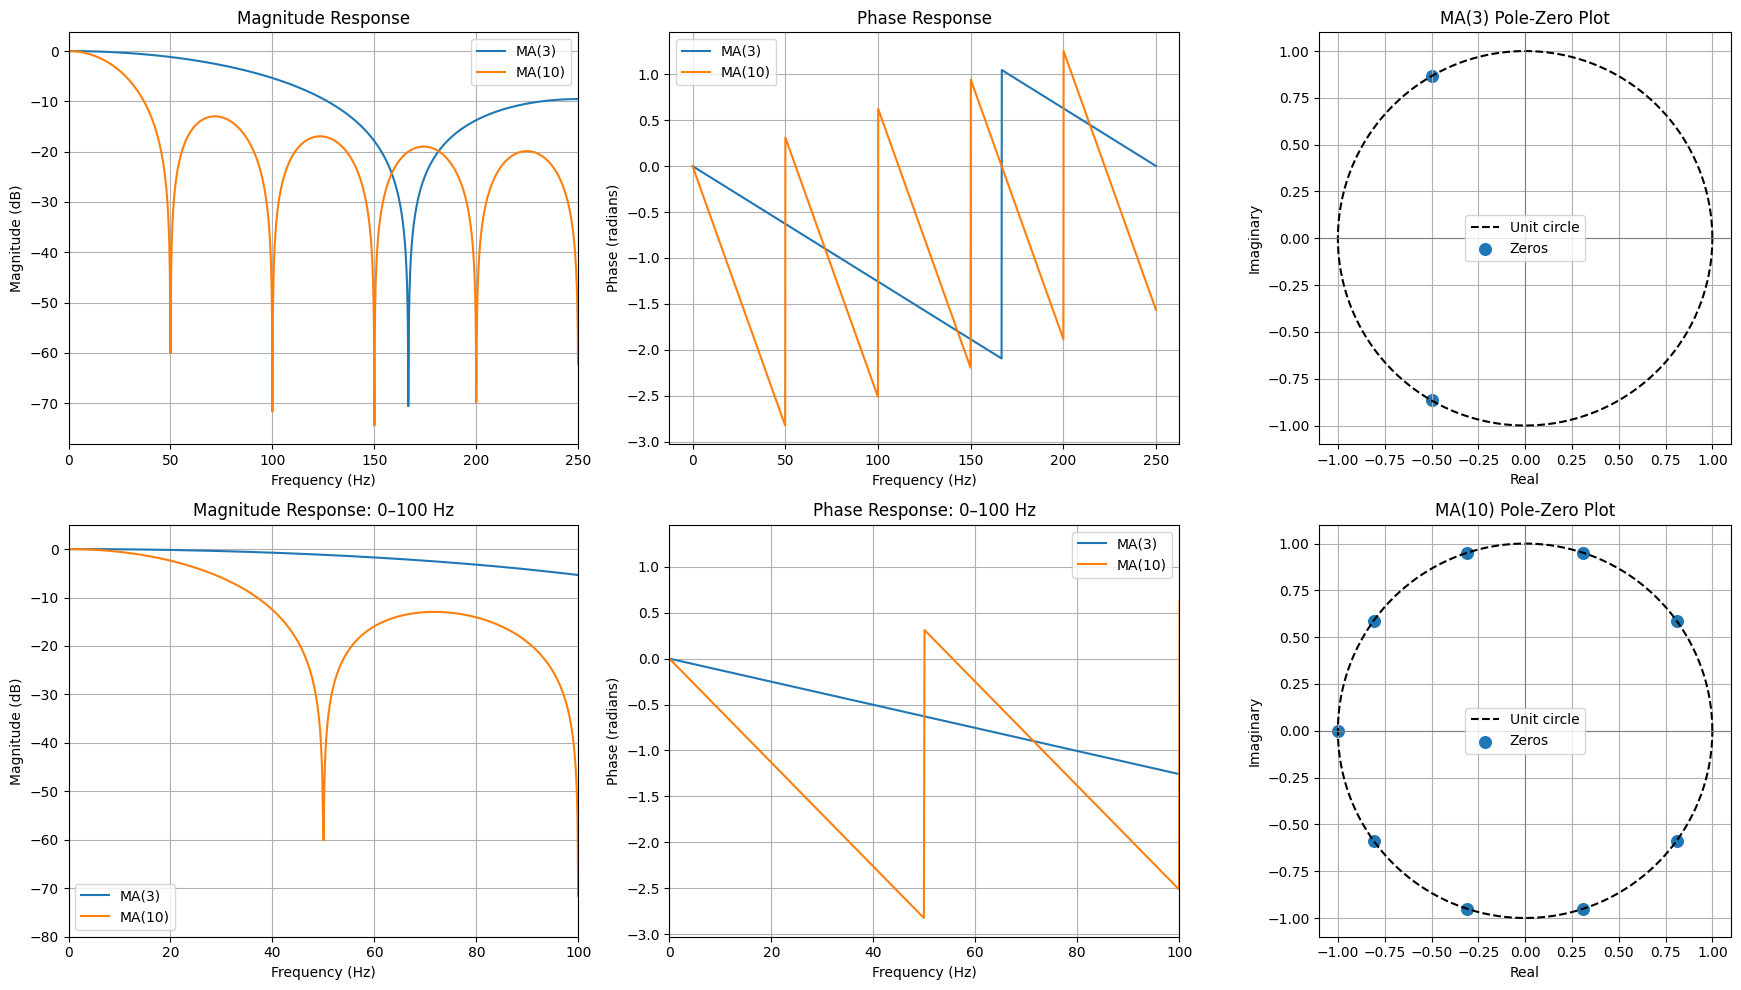

10 Hz: MA(3) =  -0.05 dB, MA(10) =  -0.57 dB
20 Hz: MA(3) =  -0.18 dB, MA(10) =  -2.40 dB
40 Hz: MA(3) =  -0.75 dB, MA(10) = -12.53 dB

First magnitude null:
MA(3):  166.7 Hz
MA(10): 50.0 Hz

Group delays:
MA(3):  1 sample
MA(10): 4.5 samples


In [23]:
# Compare MA(3) and MA(10) frequency responses and pole-zero locations
w3, h3 = freqz(b, a, worN=2048, fs=sampling_frequency)
w10, h10 = freqz(b10, a10, worN=2048, fs=sampling_frequency)

magnitude_ma3_db = 20 * np.log10(np.maximum(np.abs(h3), np.finfo(float).eps))
magnitude_ma10_db = 20 * np.log10(np.maximum(np.abs(h10), np.finfo(float).eps))

phase_ma3 = np.unwrap(np.angle(h3))
phase_ma10 = np.unwrap(np.angle(h10))

zeros_ma3 = np.roots(b)
poles_ma3 = np.roots(a)
zeros_ma10 = np.roots(b10)
poles_ma10 = np.roots(a10)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Magnitude response
axes[0, 0].plot(w3, magnitude_ma3_db, label="MA(3)")
axes[0, 0].plot(w10, magnitude_ma10_db, label="MA(10)")
axes[0, 0].set_title("Magnitude Response")
axes[0, 0].set_xlabel("Frequency (Hz)")
axes[0, 0].set_ylabel("Magnitude (dB)")
axes[0, 0].set_xlim(0, sampling_frequency / 2)
axes[0, 0].grid(True)
axes[0, 0].legend()

# Phase response
axes[0, 1].plot(w3, phase_ma3, label="MA(3)")
axes[0, 1].plot(w10, phase_ma10, label="MA(10)")
axes[0, 1].set_title("Phase Response")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Phase (radians)")
axes[0, 1].grid(True)
axes[0, 1].legend()

# Pole-zero comparison
unit_circle = np.exp(1j * theta)

for ax, zeros_filter, poles_filter, title in [
    (axes[0, 2], zeros_ma3, poles_ma3, "MA(3) Pole-Zero Plot"),
    (axes[1, 2], zeros_ma10, poles_ma10, "MA(10) Pole-Zero Plot"),
]:
    ax.plot(unit_circle.real, unit_circle.imag, "k--", label="Unit circle")
    ax.scatter(zeros_filter.real, zeros_filter.imag, s=70, label="Zeros")

    if poles_filter.size:
        ax.scatter(
            poles_filter.real,
            poles_filter.imag,
            marker="x",
            s=90,
            linewidths=2,
            label="Poles",
        )

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("Real")
    ax.set_ylabel("Imaginary")
    ax.grid(True)
    ax.legend()

# Zoomed magnitude response
axes[1, 0].plot(w3, magnitude_ma3_db, label="MA(3)")
axes[1, 0].plot(w10, magnitude_ma10_db, label="MA(10)")
axes[1, 0].set_title("Magnitude Response: 0–100 Hz")
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("Magnitude (dB)")
axes[1, 0].set_xlim(0, 100)
axes[1, 0].set_ylim(-80, 5)
axes[1, 0].grid(True)
axes[1, 0].legend()

# Zoomed phase response
axes[1, 1].plot(w3, phase_ma3, label="MA(3)")
axes[1, 1].plot(w10, phase_ma10, label="MA(10)")
axes[1, 1].set_title("Phase Response: 0–100 Hz")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Phase (radians)")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Useful comparison values
for frequency in [10, 20, 40]:
    gain_ma3 = np.interp(frequency, w3, magnitude_ma3_db)
    gain_ma10 = np.interp(frequency, w10, magnitude_ma10_db)
    print(
        f"{frequency:>2} Hz: "
        f"MA(3) = {gain_ma3:6.2f} dB, "
        f"MA(10) = {gain_ma10:6.2f} dB"
    )

print("\nFirst magnitude null:")
print(f"MA(3):  {sampling_frequency / 3:.1f} Hz")
print(f"MA(10): {sampling_frequency / 10:.1f} Hz")

print("\nGroup delays:")
print("MA(3):  1 sample")
print("MA(10): 4.5 samples")

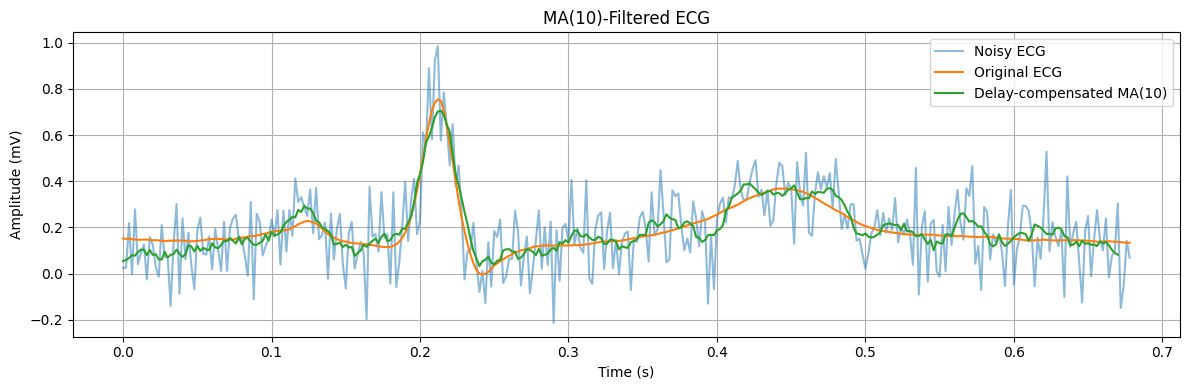

In [22]:
ma10ECG_lfilter = lfilter(b10, a10, nECG)

# Compensate for the MA(10) group delay: (10 - 1) / 2 = 4.5 samples
delay_ma10 = (N - 1) // 2
ma10ECG = ma10ECG_lfilter[delay_ma10:]

# Plot the delay-compensated filtered signal
plt.figure(figsize=(12, 4))
plt.plot(time, nECG, label="Noisy ECG", alpha=0.5)
plt.plot(time, ecg_signal, label="Original ECG")
plt.plot(
    time[:ma10ECG.size],
    ma10ECG,
    label="Delay-compensated MA(10)",
    linewidth=1.5
)
plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("MA(10)-Filtered ECG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



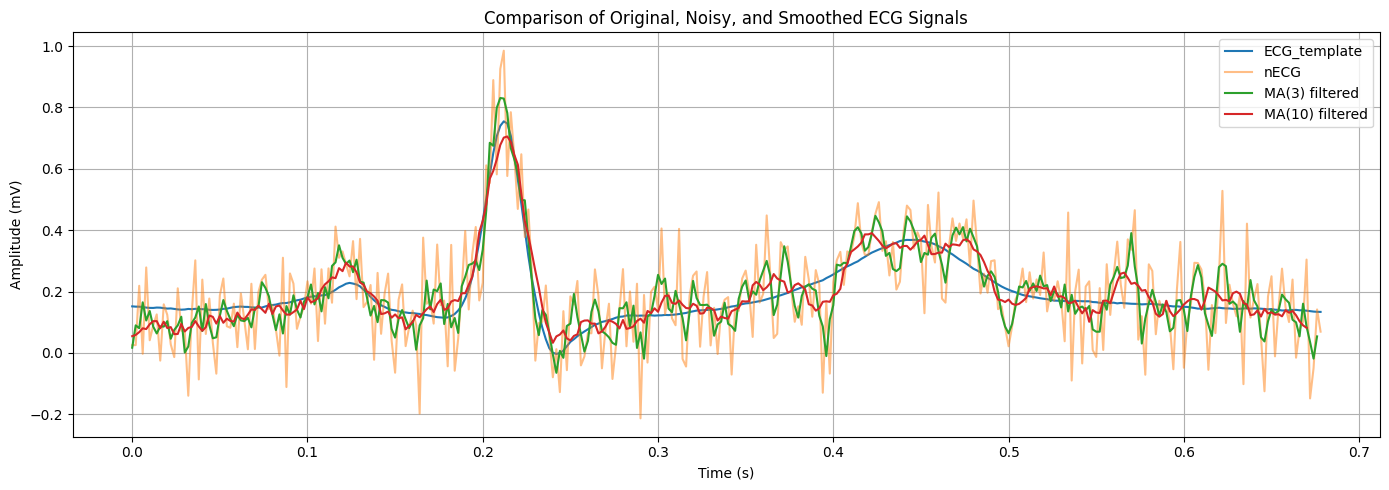

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal, label="ECG_template", linewidth=1.5)
plt.plot(time, nECG, label="nECG", alpha=0.5)
plt.plot(
    time[:ma3ECG_2.size],
    ma3ECG_2,
    label="MA(3) filtered",
    linewidth=1.5
)
plt.plot(
    time[:ma10ECG.size],
    ma10ECG,
    label="MA(10) filtered",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of Original, Noisy, and Smoothed ECG Signals")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Optimum MA(N) Filter Order

In [25]:
def ma_filter_mse(noise_free_signal, filtered_signal, N):
    """
    Calculate the MSE between a noise-free signal and an MA(N)-filtered signal.

    The MA(N) group delay is compensated before calculating the error.
    """
    noise_free_signal = np.asarray(noise_free_signal, dtype=float)
    filtered_signal = np.asarray(filtered_signal, dtype=float)

    if N < 1 or N != int(N):
        raise ValueError("N must be a positive integer")

    delay = (N - 1) / 2
    sample_indices = np.arange(filtered_signal.size)
    reference_indices = sample_indices - delay

    valid = (
        (reference_indices >= 0)
        & (reference_indices < noise_free_signal.size)
        & (sample_indices >= N - 1)
    )

    reference = np.interp(
        reference_indices[valid],
        np.arange(noise_free_signal.size),
        noise_free_signal,
    )

    error = reference - filtered_signal[valid]
    return np.mean(error**2)

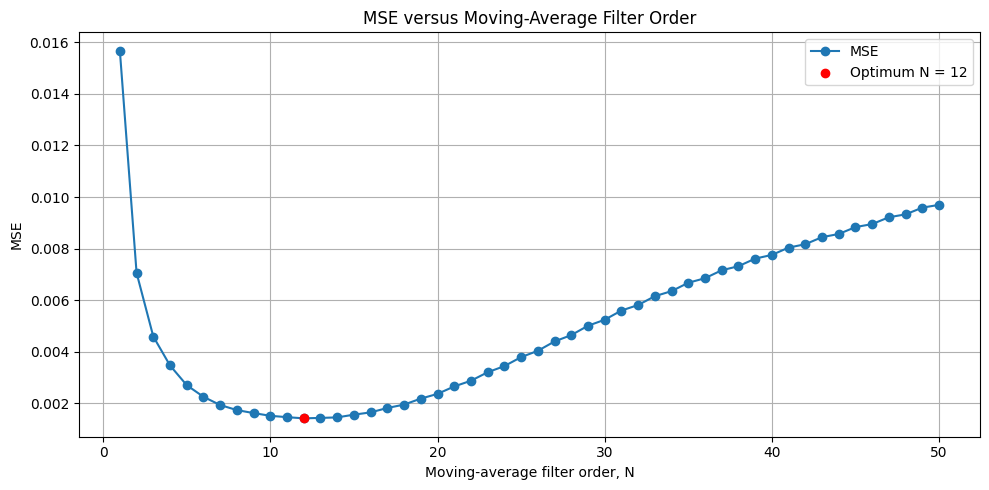

Optimal filter order: N = 12
Minimum MSE: 0.001411


In [26]:
# Test MA filter orders and calculate the delay-compensated MSE
N_values = np.arange(1, 51)
mse_values = []

for order in N_values:
    coefficients = np.ones(order) / order
    filtered_signal = lfilter(coefficients, [1.0], nECG)

    mse = ma_filter_mse(ecg_signal, filtered_signal, order)
    mse_values.append(mse)

mse_values = np.asarray(mse_values)

optimal_index = np.argmin(mse_values)
optimal_N = N_values[optimal_index]
minimum_mse = mse_values[optimal_index]

plt.figure(figsize=(10, 5))
plt.plot(N_values, mse_values, "o-", label="MSE")
plt.scatter(
    optimal_N,
    minimum_mse,
    color="red",
    zorder=3,
    label=f"Optimum N = {optimal_N}"
)

plt.xlabel("Moving-average filter order, N")
plt.ylabel("MSE")
plt.title("MSE versus Moving-Average Filter Order")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal filter order: N = {optimal_N}")
print(f"Minimum MSE: {minimum_mse:.6f}")

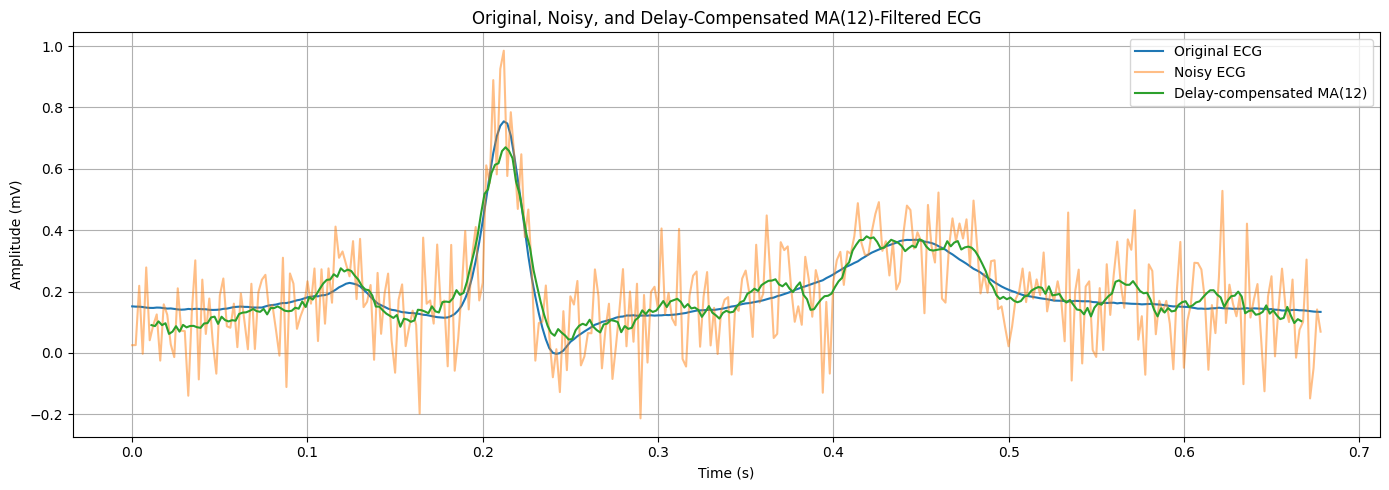

In [27]:
# MA(12) filter with delay compensation
N12 = 12
b12 = np.ones(N12) / N12
a12 = np.array([1.0])

ma12ECG_lfilter = lfilter(b12, a12, nECG)

# MA(12) group delay: (12 - 1) / 2 = 5.5 samples
delay_ma12 = (N12 - 1) / 2
valid = np.arange(N12 - 1, ma12ECG_lfilter.size)
compensated_time = time[valid] - delay_ma12 / sampling_frequency

plt.figure(figsize=(14, 5))
plt.plot(time, ecg_signal, label="Original ECG", linewidth=1.5)
plt.plot(time, nECG, label="Noisy ECG", alpha=0.5)
plt.plot(
    compensated_time,
    ma12ECG_lfilter[valid],
    label="Delay-compensated MA(12)",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Original, Noisy, and Delay-Compensated MA(12)-Filtered ECG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Savitzky-Golay Filter

In [28]:
from scipy.signal import savgol_filter

sg311ECG = savgol_filter(nECG, window_length=11, polyorder=3)

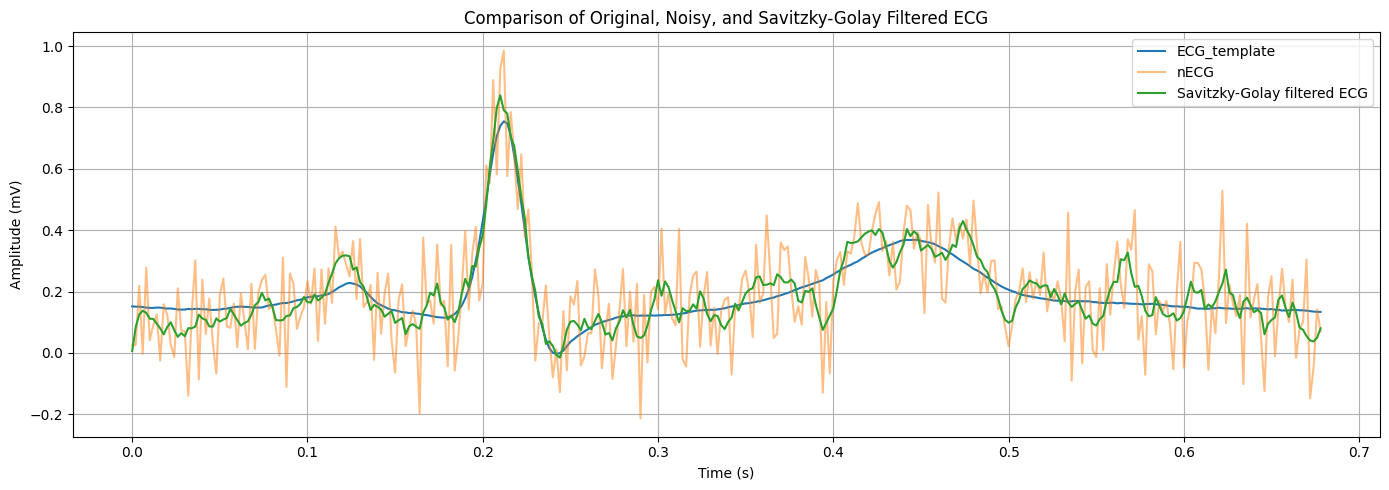

In [29]:
plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal, label="ECG_template", linewidth=1.5)
plt.plot(time, nECG, label="nECG", alpha=0.5)
plt.plot(time, sg311ECG, label="Savitzky-Golay filtered ECG", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of Original, Noisy, and Savitzky-Golay Filtered ECG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

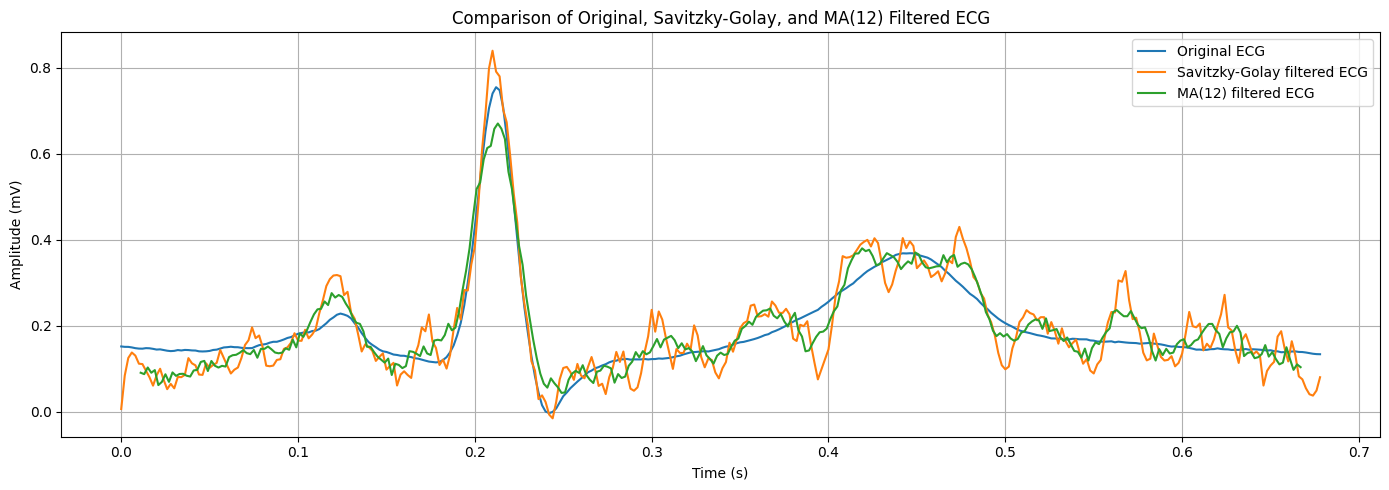

In [31]:
plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal, label="Original ECG", linewidth=1.5)
plt.plot(time, sg311ECG, label="Savitzky-Golay filtered ECG", linewidth=1.5)

# Delay-compensated MA(12)
plt.plot(
    compensated_time,
    ma12ECG_lfilter[valid],
    label="MA(12) filtered ECG",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of Original, Savitzky-Golay, and MA(12) Filtered ECG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Optimum SG(N,L) filter parameters

In [32]:
def sg_filter_mse(reference_signal, noisy_signal, window_length, polyorder):
    """
    Calculate the MSE of a Savitzky-Golay filtered signal.

    Edge samples are excluded because Savitzky-Golay edge handling can
    introduce boundary effects.
    """
    reference_signal = np.asarray(reference_signal, dtype=float)
    noisy_signal = np.asarray(noisy_signal, dtype=float)

    if window_length % 2 == 0 or window_length < 3:
        raise ValueError("window_length must be an odd integer >= 3")

    if polyorder < 0 or polyorder >= window_length:
        raise ValueError("polyorder must satisfy 0 <= polyorder < window_length")

    if reference_signal.size != noisy_signal.size:
        raise ValueError("Signals must have the same length")

    filtered_signal = savgol_filter(
        noisy_signal,
        window_length=window_length,
        polyorder=polyorder
    )

    half_window = window_length // 2
    valid_slice = slice(half_window, -half_window)

    error = (
        reference_signal[valid_slice]
        - filtered_signal[valid_slice]
    )

    return np.mean(error**2)


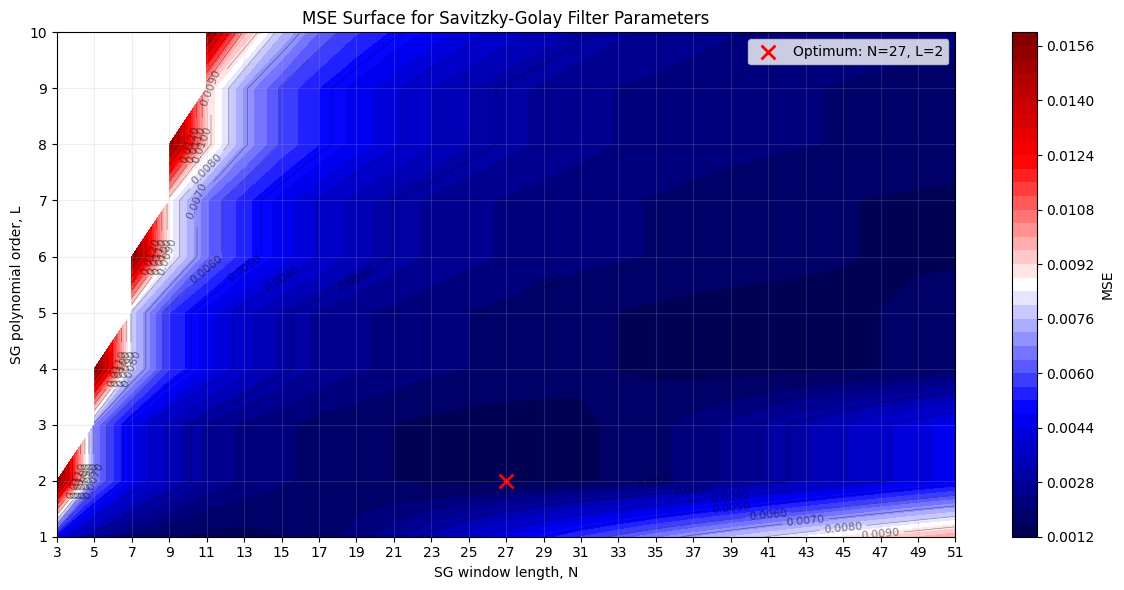

Optimal window length, N: 27
Optimal polynomial order, L: 2
Minimum MSE: 0.00139175


In [44]:

# Parameter ranges
window_lengths = np.arange(3, 52, 2)
polyorders = np.arange(1, 11)

mse_grid = np.full(
    (polyorders.size, window_lengths.size),
    np.nan
)

for row, polyorder in enumerate(polyorders):
    for col, window_length in enumerate(window_lengths):
        if polyorder < window_length:
            mse_grid[row, col] = sg_filter_mse(
                ecg_signal,
                nECG,
                window_length,
                polyorder
            )

# Find optimum parameters
optimal_row, optimal_col = np.unravel_index(
    np.nanargmin(mse_grid),
    mse_grid.shape
)

optimal_window_length = window_lengths[optimal_col]
optimal_polyorder = polyorders[optimal_row]
minimum_mse = mse_grid[optimal_row, optimal_col]

plt.figure(figsize=(12, 6))

mesh = plt.contourf(
    window_lengths,
    polyorders,
    mse_grid,
    levels=40,
    cmap="seismic"
)

# Add contour lines for clearer discretisation
contours = plt.contour(
    window_lengths,
    polyorders,
    mse_grid,
    levels=15,
    colors="black",
    linewidths=0.4,
    alpha=0.5
)

plt.clabel(contours, inline=True, fontsize=8, fmt="%.4f")

plt.scatter(
    optimal_window_length,
    optimal_polyorder,
    color="red",
    marker="x",
    s=100,
    linewidths=2,
    label=(
        f"Optimum: N={optimal_window_length}, "
        f"L={optimal_polyorder}"
    )
)

plt.colorbar(mesh, label="MSE")
plt.xlabel("SG window length, N")
plt.ylabel("SG polynomial order, L")
plt.title("MSE Surface for Savitzky-Golay Filter Parameters")
plt.xticks(window_lengths)
plt.yticks(polyorders)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal window length, N: {optimal_window_length}")
print(f"Optimal polynomial order, L: {optimal_polyorder}")
print(f"Minimum MSE: {minimum_mse:.8f}")

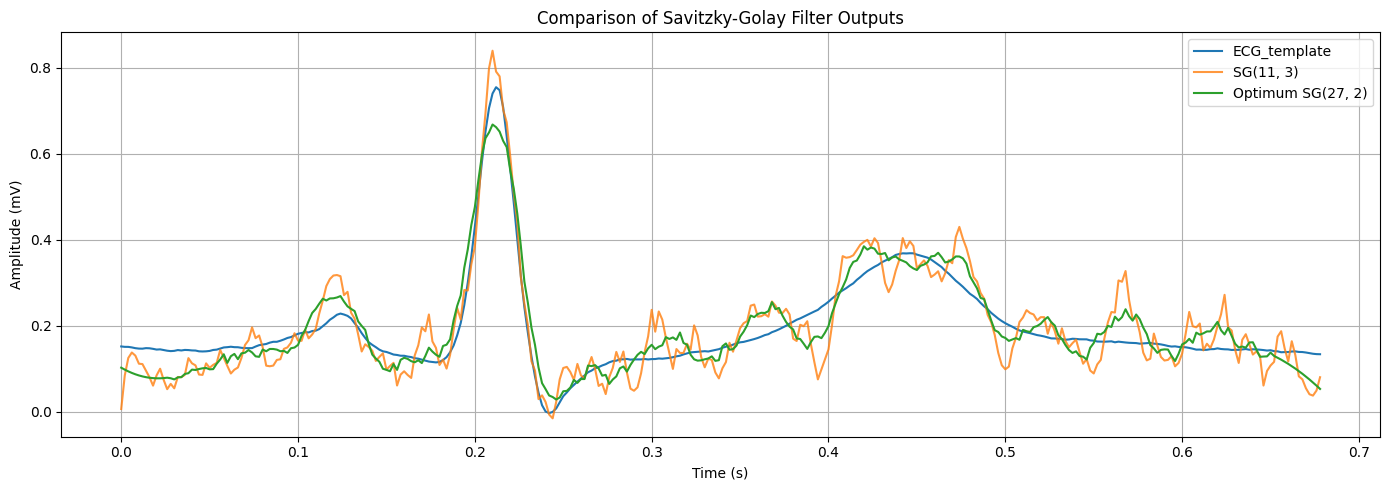

In [45]:
# Apply the optimum Savitzky-Golay filter
optimal_sgECG = savgol_filter(
    nECG,
    window_length=optimal_window_length,
    polyorder=optimal_polyorder
)

plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal, label="ECG_template", linewidth=1.5)
plt.plot(time, sg311ECG, label="SG(11, 3)", alpha=0.8)
plt.plot(
    time,
    optimal_sgECG,
    label=f"Optimum SG({optimal_window_length}, {optimal_polyorder})",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of Savitzky-Golay Filter Outputs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

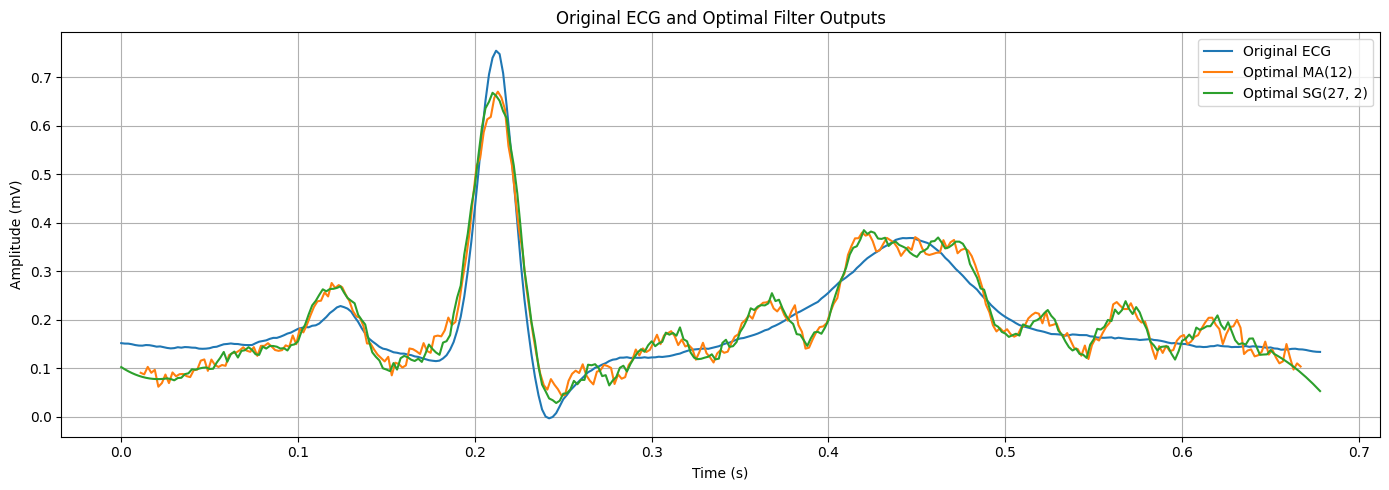

In [37]:
plt.figure(figsize=(14, 5))

plt.plot(
    time,
    ecg_signal,
    label="Original ECG",
    linewidth=1.5
)

plt.plot(
    compensated_time,
    ma12ECG_lfilter[valid],
    label="Optimal MA(12)",
    linewidth=1.5
)

plt.plot(
    time,
    optimal_sgECG,
    label=f"Optimal SG({optimal_window_length}, {optimal_polyorder})",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Original ECG and Optimal Filter Outputs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Ensemble Averaging

Available arrays: ['ABR_rec']
ABR recording shape: (2000000, 2)


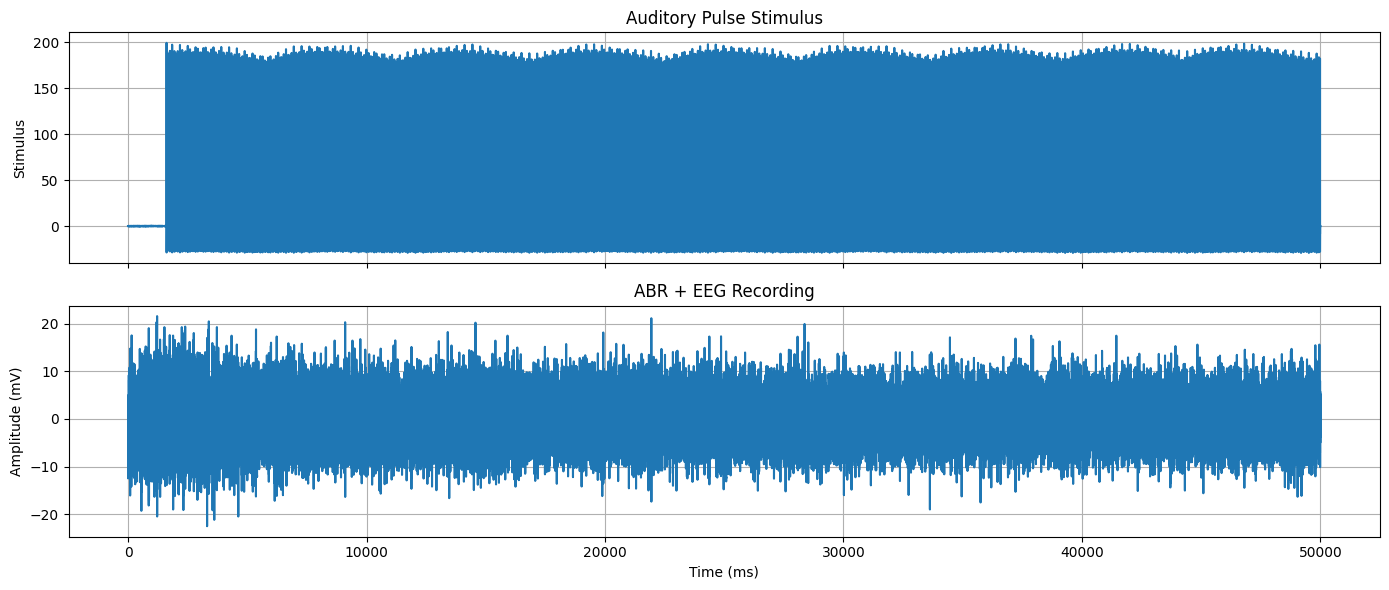

In [46]:
abr_data = np.load("signal_sources/ABR_rec.npz")

print("Available arrays:", abr_data.files)

# Use the recorded array from the NPZ file
abr_recording = np.asarray(abr_data[abr_data.files[0]])

print("ABR recording shape:", abr_recording.shape)

abr_sampling_frequency = 40_000  # Hz
abr_amplitude_units = "mV"

# The recording contains:
# column 1: auditory pulse stimulus
# column 2: ABR + EEG
stimulus = abr_recording[:, 0]
abr_eeg = abr_recording[:, 1]

abr_time = np.arange(abr_recording.shape[0]) / abr_sampling_frequency

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(abr_time * 1000, stimulus)
axes[0].set_ylabel("Stimulus")
axes[0].set_title("Auditory Pulse Stimulus")
axes[0].grid(True)

axes[1].plot(abr_time * 1000, abr_eeg)
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel(f"Amplitude ({abr_amplitude_units})")
axes[1].set_title("ABR + EEG Recording")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Stimulus range: -29.0000 to 199.6000
ABR range: -21.0093 to 21.1368


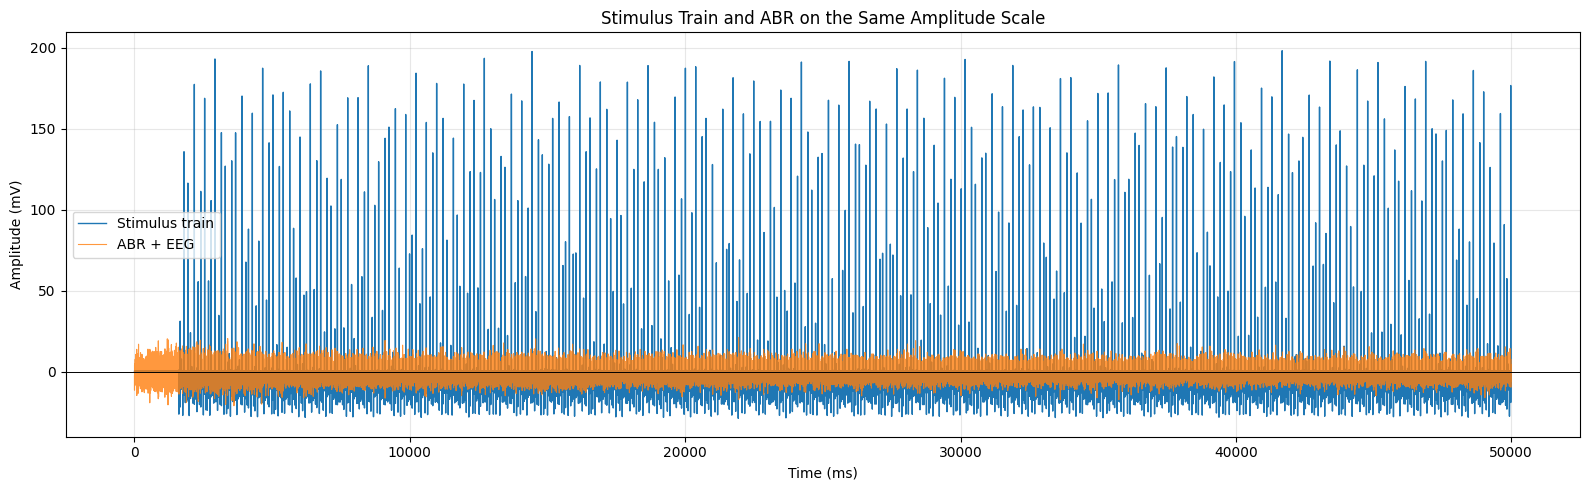

In [48]:
# Plot stimulus train and ABR on the same amplitude scale
abr_baseline_corrected = abr_eeg - np.median(abr_eeg)

# Downsample only for efficient plotting of the complete recording
plot_step = max(1, abr_time.size // 100_000)
plot_indices = np.arange(0, abr_time.size, plot_step)

stimulus_plot = stimulus[plot_indices]
abr_plot = abr_baseline_corrected[plot_indices]
time_plot = abr_time[plot_indices] * 1000

print(f"Stimulus range: {stimulus.min():.4f} to {stimulus.max():.4f}")
print(f"ABR range: {abr_plot.min():.4f} to {abr_plot.max():.4f}")

plt.figure(figsize=(16, 5))
plt.plot(time_plot, stimulus_plot, label="Stimulus train", linewidth=1.0)
plt.plot(time_plot, abr_plot, label="ABR + EEG", linewidth=0.8, alpha=0.8)

plt.axhline(0, color="black", linewidth=0.7)
plt.xlabel("Time (ms)")
plt.ylabel(f"Amplitude ({abr_amplitude_units})")
plt.title("Stimulus Train and ABR on the Same Amplitude Scale")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Detected samples: 5743
Detected stimulus occurrences: 1034
Occurrence times (ms): [ 1611.725  1658.525  1705.35  ... 49890.325 49937.125 49983.925]


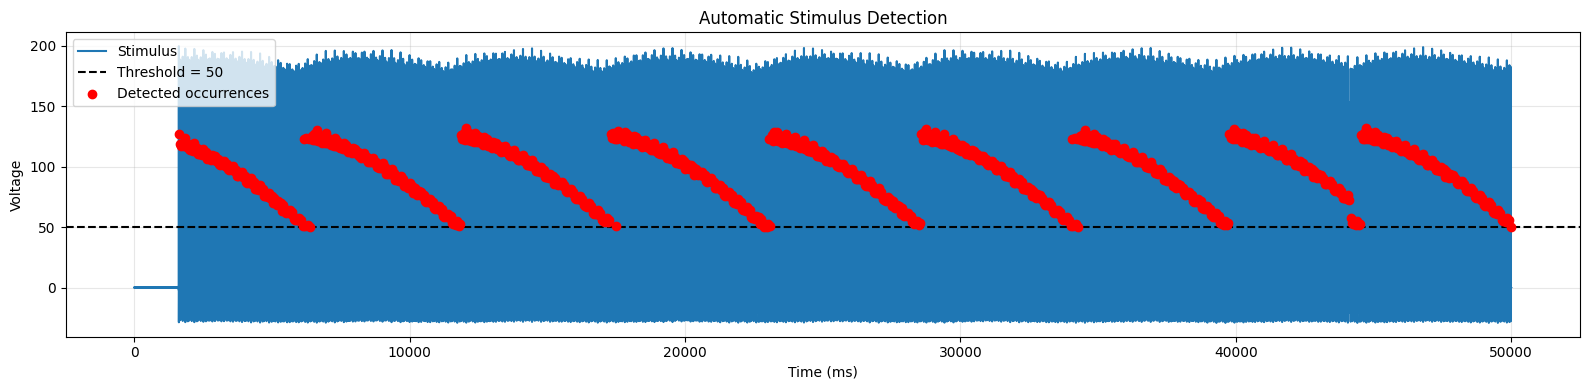

In [51]:
voltage_threshold = 50

# Boolean indexing with np.where
stimulus_indices = np.where(stimulus >= voltage_threshold)[0]

# Identify the start of each detected stimulus occurrence
occurrence_starts = stimulus_indices[
    np.r_[True, np.diff(stimulus_indices) > 1]
]

occurrence_times_ms = abr_time[occurrence_starts] * 1000

print(f"Detected samples: {stimulus_indices.size}")
print(f"Detected stimulus occurrences: {occurrence_starts.size}")
print("Occurrence times (ms):", occurrence_times_ms)

plt.figure(figsize=(16, 4))
plt.plot(abr_time * 1000, stimulus, label="Stimulus")
plt.axhline(
    voltage_threshold,
    color="black",
    linestyle="--",
    label=f"Threshold = {voltage_threshold}"
)
plt.scatter(
    occurrence_times_ms,
    stimulus[occurrence_starts],
    color="red",
    zorder=3,
    label="Detected occurrences"
)

plt.xlabel("Time (ms)")
plt.ylabel("Voltage")
plt.title("Automatic Stimulus Detection")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Leading-edge indices: [  64469   66341   68214 ... 1995613 1997485 1999357]
Leading-edge times (ms): [ 1611.725  1658.525  1705.35  ... 49890.325 49937.125 49983.925]
Leading-edge amplitudes: [127.1 119.  117.1 ...  54.3  55.9  50. ]


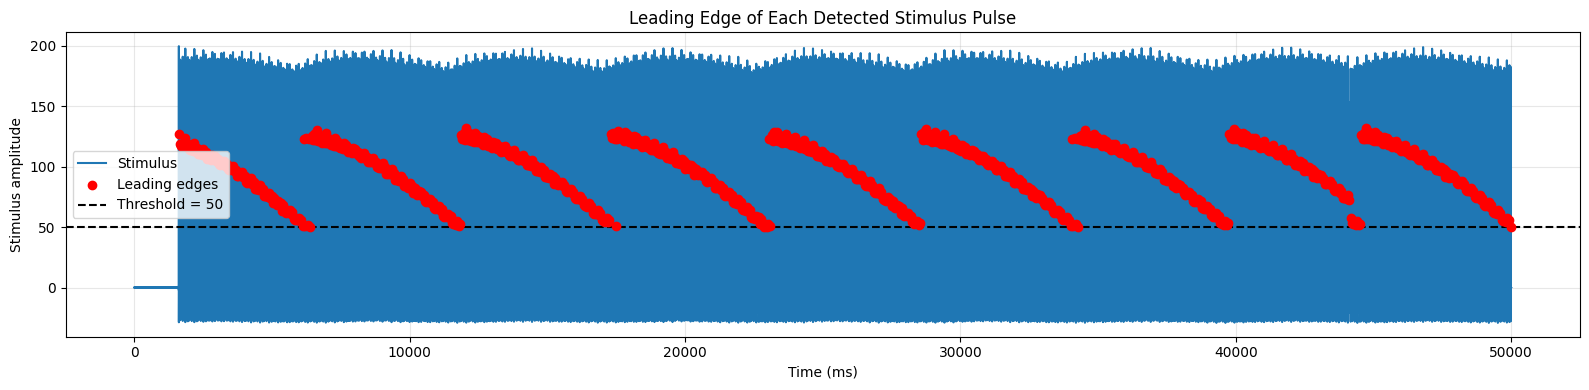

In [52]:
# Extract the leading-edge sample of each detected stimulus pulse
above_threshold = stimulus >= voltage_threshold

leading_edge_indices = np.flatnonzero(
    above_threshold & ~np.r_[False, above_threshold[:-1]]
)

stimulus_points = stimulus[leading_edge_indices]
stimulus_times_ms = abr_time[leading_edge_indices] * 1000

print("Leading-edge indices:", leading_edge_indices)
print("Leading-edge times (ms):", stimulus_times_ms)
print("Leading-edge amplitudes:", stimulus_points)

plt.figure(figsize=(16, 4))
plt.plot(abr_time * 1000, stimulus, label="Stimulus")
plt.scatter(
    stimulus_times_ms,
    stimulus_points,
    color="red",
    zorder=3,
    label="Leading edges"
)
plt.axhline(
    voltage_threshold,
    color="black",
    linestyle="--",
    label=f"Threshold = {voltage_threshold}"
)

plt.xlabel("Time (ms)")
plt.ylabel("Stimulus amplitude")
plt.title("Leading Edge of Each Detected Stimulus Pulse")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Epoch shape: (1034, 480)
Window: -2.000 to 9.975 ms
Extracted epochs: 1034


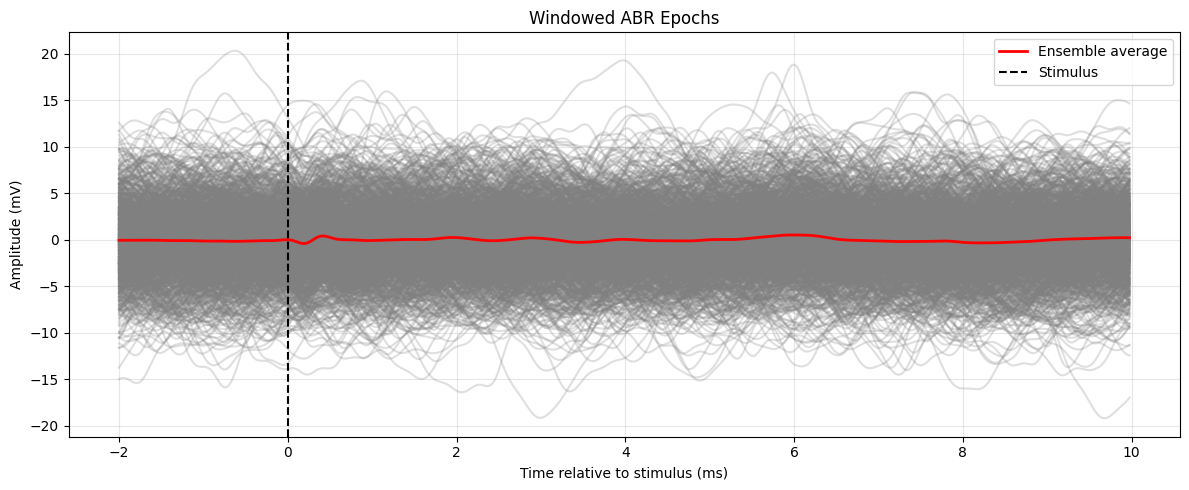

In [53]:
# Window ABR epochs around each detected stimulus leading edge
pre_samples = int(2e-3 * abr_sampling_frequency)   # 80 samples
post_samples = int(10e-3 * abr_sampling_frequency)  # 400 samples
epoch_length = pre_samples + post_samples           # 480 samples

relative_samples = np.arange(-pre_samples, post_samples)
epoch_time_ms = relative_samples / abr_sampling_frequency * 1000

epoch_starts = leading_edge_indices - pre_samples
epoch_ends = leading_edge_indices + post_samples

# Keep only complete epochs within the recording
complete_epochs = (
    (epoch_starts >= 0)
    & (epoch_ends <= abr_eeg.size)
)

abr_epochs = np.array([
    abr_eeg[start:end]
    for start, end, is_complete in zip(
        epoch_starts, epoch_ends, complete_epochs
    )
    if is_complete
])

epoch_stimulus_times_ms = (
    abr_time[leading_edge_indices[complete_epochs]] * 1000
)

print(f"Epoch shape: {abr_epochs.shape}")
print(f"Window: {epoch_time_ms[0]:.3f} to {epoch_time_ms[-1]:.3f} ms")
print(f"Extracted epochs: {abr_epochs.shape[0]}")

plt.figure(figsize=(12, 5))
for epoch in abr_epochs:
    plt.plot(epoch_time_ms, epoch, alpha=0.25, color="gray")

plt.plot(
    epoch_time_ms,
    np.mean(abr_epochs, axis=0),
    color="red",
    linewidth=2,
    label="Ensemble average"
)

plt.axvline(0, color="black", linestyle="--", label="Stimulus")
plt.xlabel("Time relative to stimulus (ms)")
plt.ylabel(f"Amplitude ({abr_amplitude_units})")
plt.title("Windowed ABR Epochs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

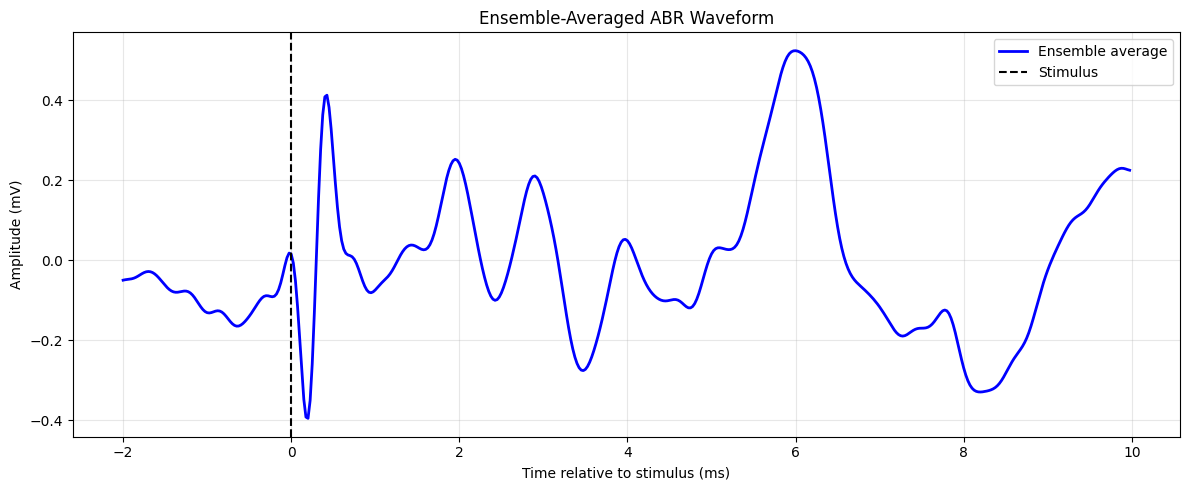

In [54]:
plt.figure(figsize=(12, 5))
plt.plot(
    epoch_time_ms,
    np.mean(abr_epochs, axis=0),
    color="blue",
    linewidth=2,
    label="Ensemble average"
)
plt.axvline(0, color="black", linestyle="--", label="Stimulus")
plt.xlabel("Time relative to stimulus (ms)")
plt.ylabel(f"Amplitude ({abr_amplitude_units})")
plt.title("Ensemble-Averaged ABR Waveform")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Improvement of SNR

In [56]:
def progressive_mse(epochs, template):
    """
    Calculate the MSE between a template and progressive ensemble averages.

    Parameters
    ----------
    epochs : numpy.ndarray
        Array with shape (M, N), where M is the number of epochs.
    template : numpy.ndarray
        Reference ABR template with length N.

    Returns
    -------
    numpy.ndarray
        Progressive MSE values for k = 1, ..., M.
    """
    epochs = np.asarray(epochs, dtype=float)
    template = np.asarray(template, dtype=float).ravel()

    if epochs.ndim != 2:
        raise ValueError("epochs must be a 2D array with shape (M, N)")

    if epochs.shape[1] != template.size:
        raise ValueError("Each epoch must have the same length as the template")

    cumulative_average = np.cumsum(epochs, axis=0)
    sample_counts = np.arange(1, epochs.shape[0] + 1)[:, None]
    progressive_averages = cumulative_average / sample_counts

    progressive_mses = np.mean(
        (progressive_averages - template[None, :]) ** 2,
        axis=1
    )

    return progressive_mses



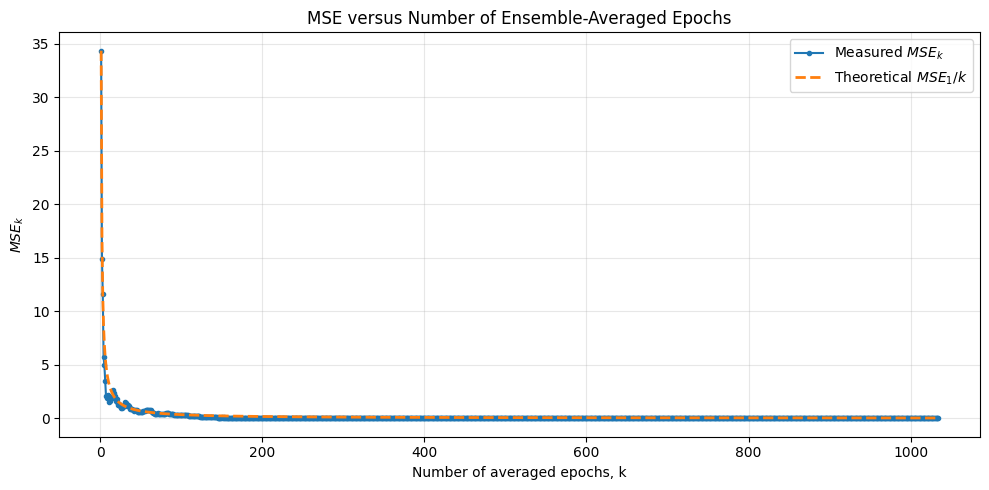

MSE for one epoch: 3.435104e+01
MSE for all epochs: 0.000000e+00


In [57]:
# MSE_k for progressive ensemble averaging
abr_template = np.mean(abr_epochs, axis=0)
mse_k = progressive_mse(abr_epochs, abr_template)

k_values = np.arange(1, abr_epochs.shape[0] + 1)

# Theoretical 1/k behaviour, scaled to the measured MSE at k = 1
theoretical_mse = mse_k[0] / k_values

plt.figure(figsize=(10, 5))
plt.plot(k_values, mse_k, "o-", markersize=3, label=r"Measured $MSE_k$")
plt.plot(
    k_values,
    theoretical_mse,
    "--",
    linewidth=2,
    label=r"Theoretical $MSE_1/k$"
)

plt.xlabel("Number of averaged epochs, k")
plt.ylabel(r"$MSE_k$")
plt.title("MSE versus Number of Ensemble-Averaged Epochs")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"MSE for one epoch: {mse_k[0]:.6e}")
print(f"MSE for all epochs: {mse_k[-1]:.6e}")

### Signal with repetitive patterns

In [66]:
# Load the recorded ECG signal
ecg_rec = np.load("signal_sources/ECG_rec.npz")

ecg_rec_sampling_frequency = 128  # Hz
ecg_rec_amplitude_units = "mV"


Available arrays: ['ECG_rec']
Recording shape: (7680, 1)
Amplitude range: -0.6950 to 1.8250 mV


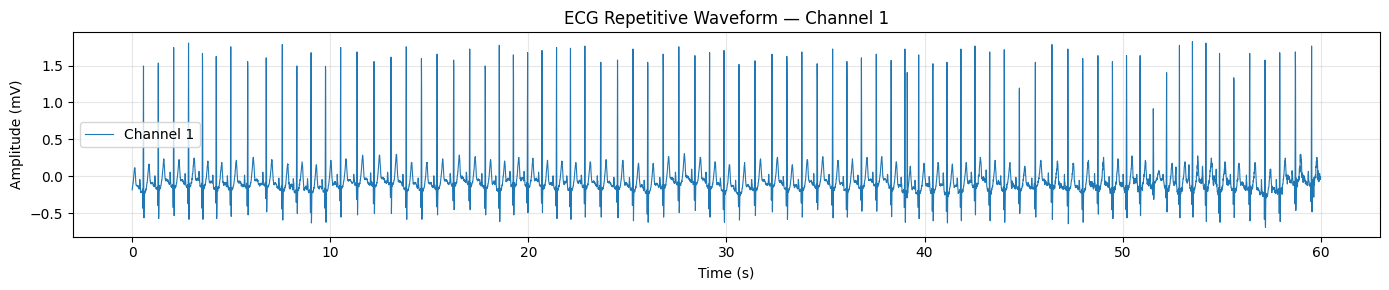

In [67]:
# Inspect and plot the repetitive ECG recording
print("Available arrays:", ecg_rec.files)

ecg_recording = np.asarray(ecg_rec[ecg_rec.files[0]]).squeeze()

if ecg_recording.ndim == 1:
    ecg_recording = ecg_recording[:, None]

# Ensure samples are in rows
if ecg_recording.shape[0] < ecg_recording.shape[1]:
    ecg_recording = ecg_recording.T

ecg_time = np.arange(ecg_recording.shape[0]) / ecg_rec_sampling_frequency

print("Recording shape:", ecg_recording.shape)
print(
    f"Amplitude range: {ecg_recording.min():.4f} to "
    f"{ecg_recording.max():.4f} {ecg_rec_amplitude_units}"
)

fig, axes = plt.subplots(
    ecg_recording.shape[1],
    1,
    figsize=(14, 3 * ecg_recording.shape[1]),
    squeeze=False
)

for channel in range(ecg_recording.shape[1]):
    ax = axes[channel, 0]
    ax.plot(
        ecg_time,
        ecg_recording[:, channel],
        linewidth=0.8,
        label=f"Channel {channel + 1}"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"Amplitude ({ecg_rec_amplitude_units})")
    ax.set_title(f"ECG Repetitive Waveform — Channel {channel + 1}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

Detected R-peaks: 80
Selected R-peak index: 3921
ECG_template shape: (89,)


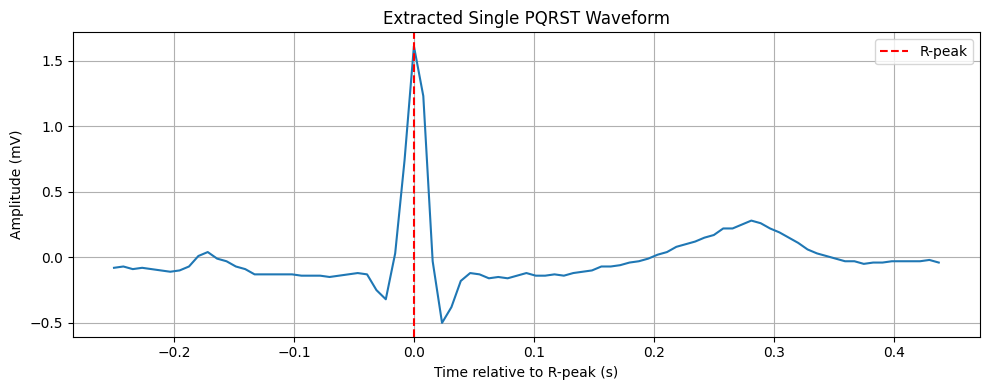

In [68]:
from scipy.signal import find_peaks

# Select the first ECG channel
ecg_channel = ecg_recording[:, 0].astype(float)

# Remove the DC component
ecg_channel -= np.median(ecg_channel)

# Detect R-peaks
peak_distance = int(0.4 * ecg_rec_sampling_frequency)
peak_prominence = 0.5 * np.std(ecg_channel)

r_peaks, properties = find_peaks(
    ecg_channel,
    distance=peak_distance,
    prominence=peak_prominence
)

if r_peaks.size < 3:
    raise ValueError("Could not detect enough R-peaks.")

# Select a central complete heartbeat
r_peak = r_peaks[r_peaks.size // 2]

pre_samples = int(0.25 * ecg_rec_sampling_frequency)
post_samples = int(0.45 * ecg_rec_sampling_frequency)

start = r_peak - pre_samples
end = r_peak + post_samples

if start < 0 or end > ecg_channel.size:
    raise ValueError("Selected heartbeat is not fully contained in the recording.")

# Define the extracted single PQRST waveform
ECG_template = ecg_channel[start:end].copy()
ECG_template_time = (
    np.arange(ECG_template.size) - pre_samples
) / ecg_rec_sampling_frequency

print(f"Detected R-peaks: {r_peaks.size}")
print(f"Selected R-peak index: {r_peak}")
print(f"ECG_template shape: {ECG_template.shape}")

plt.figure(figsize=(10, 4))
plt.plot(ECG_template_time, ECG_template)
plt.axvline(0, color="red", linestyle="--", label="R-peak")
plt.xlabel("Time relative to R-peak (s)")
plt.ylabel(f"Amplitude ({ecg_rec_amplitude_units})")
plt.title("Extracted Single PQRST Waveform")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
# Add Gaussian white noise at an SNR of 5 dB to ECG_rec
target_snr_db = 5

signal_power = np.mean(ecg_recording**2)
target_noise_power = signal_power / (10 ** (target_snr_db / 10))

noise = np.random.randn(*ecg_recording.shape)
noise *= np.sqrt(target_noise_power / np.mean(noise**2))

nECG = ecg_recording + noise

print(f"Target SNR: {target_snr_db} dB")
print(f"Noise power: {target_noise_power:.6f}")

Target SNR: 5 dB
Noise power: 0.022731


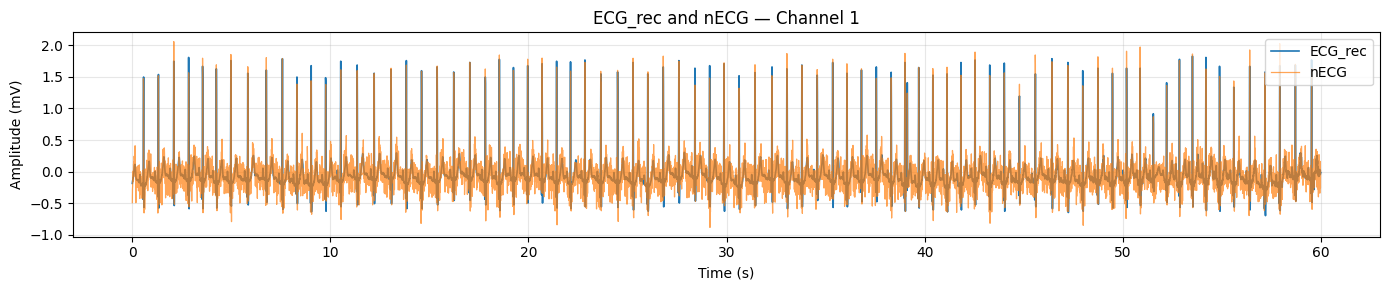

In [70]:
fig, axes = plt.subplots(
    ecg_recording.shape[1],
    1,
    figsize=(14, 3 * ecg_recording.shape[1]),
    squeeze=False,
    sharex=True
)

for channel in range(ecg_recording.shape[1]):
    ax = axes[channel, 0]
    ax.plot(
        ecg_time,
        ecg_recording[:, channel],
        label="ECG_rec",
        linewidth=1.2
    )
    ax.plot(
        ecg_time,
        nECG[:, channel],
        label="nECG",
        alpha=0.7,
        linewidth=0.9
    )
    ax.set_ylabel(f"Amplitude ({ecg_rec_amplitude_units})")
    ax.set_title(f"ECG_rec and nECG — Channel {channel + 1}")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1, 0].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

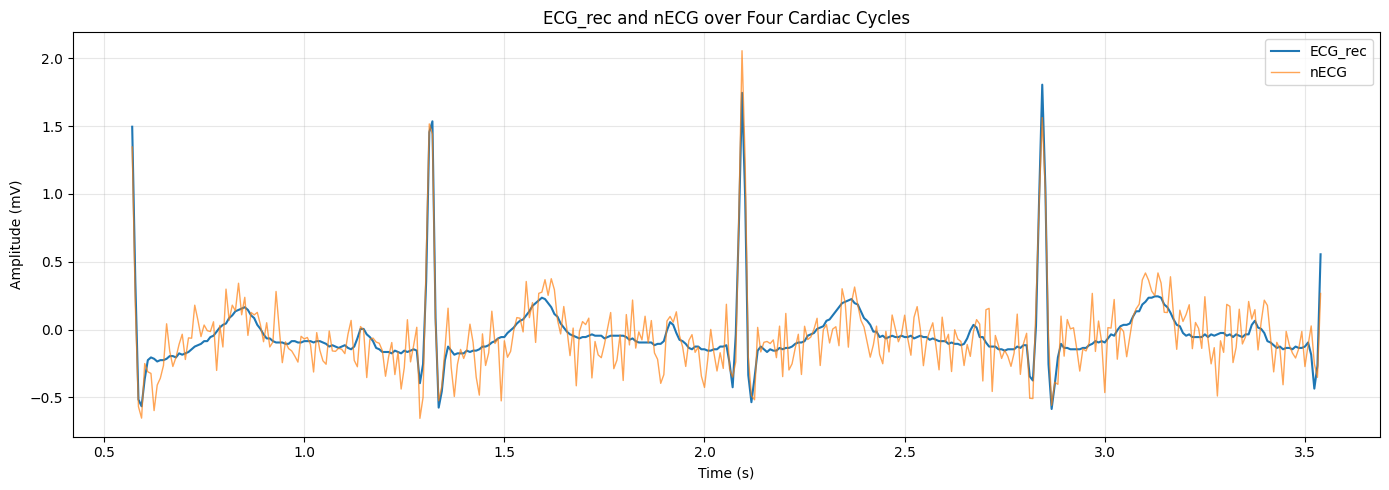

In [71]:
# Plot approximately four consecutive ECG cycles from channel 1
channel = 0

if r_peaks.size < 5:
    raise ValueError("At least five detected R-peaks are required.")

# Four cycles are defined by five consecutive R-peaks
start = r_peaks[1]
end = r_peaks[5]

segment_slice = slice(start, end)

plt.figure(figsize=(14, 5))
plt.plot(
    ecg_time[segment_slice],
    ecg_recording[segment_slice, channel],
    label="ECG_rec",
    linewidth=1.5
)
plt.plot(
    ecg_time[segment_slice],
    nECG[segment_slice, channel],
    label="nECG",
    alpha=0.7,
    linewidth=1.0
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({ecg_rec_amplitude_units})")
plt.title("ECG_rec and nECG over Four Cardiac Cycles")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Segmenting ECG into separate epochs and ensemble averaging

In [75]:
# Calculate normalized cross-correlation between ECG_template and noisy ECG

template = np.asarray(ECG_template, dtype=float).ravel()
noisy_ecg = np.asarray(nECG[:, 0], dtype=float).ravel()

template_centered = template - np.mean(template)
template_norm = np.linalg.norm(template_centered)

# Create all signal segments with the same length as the template
segments = np.lib.stride_tricks.sliding_window_view(
    noisy_ecg,
    window_shape=template.size
)

segments_centered = segments - np.mean(segments, axis=1, keepdims=True)

correlation_denominator = (
    np.linalg.norm(segments_centered, axis=1) * template_norm
)

normalised_xcorr = np.divide(
    segments_centered @ template_centered,
    correlation_denominator,
    out=np.zeros_like(correlation_denominator),
    where=correlation_denominator > 0
)

# Time associated with the start of each template match
xcorr_time = np.arange(normalised_xcorr.size) / ecg_rec_sampling_frequency

# Best matching epoch
best_start = np.argmax(normalised_xcorr)

print(f"Maximum normalized cross-correlation: "
      f"{normalised_xcorr[best_start]:.4f}")
print(f"Best matching epoch start time: {xcorr_time[best_start]:.3f} s")
print(f"Best matching sample index: {best_start}")


Maximum normalized cross-correlation: 0.8988
Best matching epoch start time: 25.773 s
Best matching sample index: 3299


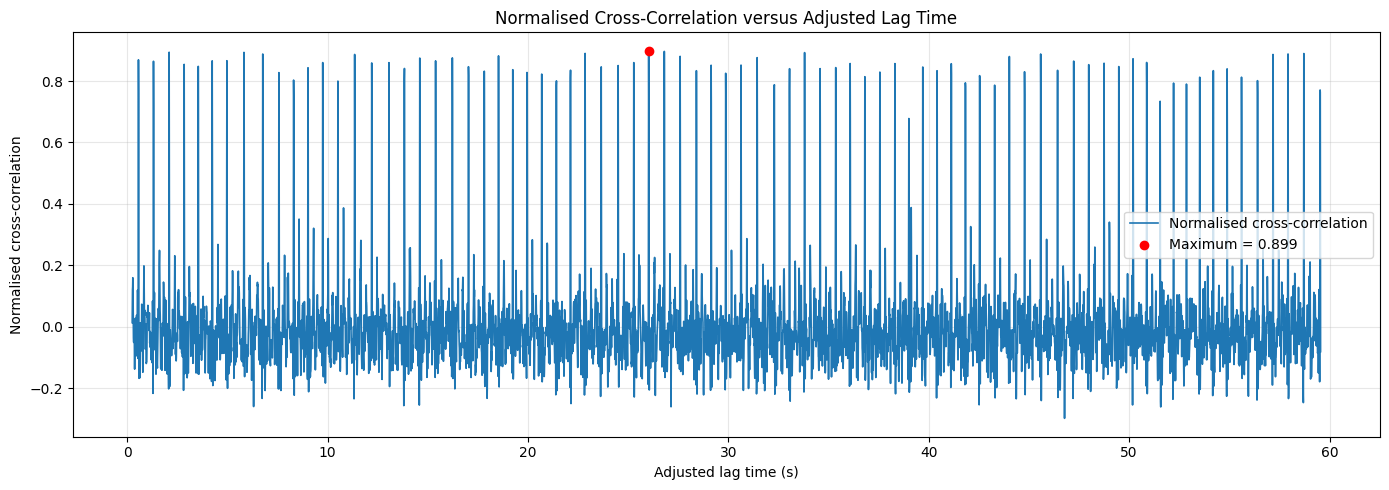

In [76]:
# Adjust the lag axis to reference the R-peak position within ECG_template
adjusted_lag_samples = np.arange(normalised_xcorr.size) + pre_samples
adjusted_lag_time = adjusted_lag_samples / ecg_rec_sampling_frequency

best_adjusted_time = adjusted_lag_time[best_start]

plt.figure(figsize=(14, 5))
plt.plot(
    adjusted_lag_time,
    normalised_xcorr,
    linewidth=1.2,
    label="Normalised cross-correlation"
)
plt.scatter(
    best_adjusted_time,
    normalised_xcorr[best_start],
    color="red",
    zorder=3,
    label=f"Maximum = {normalised_xcorr[best_start]:.3f}"
)

plt.xlabel("Adjusted lag time (s)")
plt.ylabel("Normalised cross-correlation")
plt.title("Normalised Cross-Correlation versus Adjusted Lag Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Correlation threshold: 0.7
Detected ECG pulses: 78
Pulse matrix shape: (78, 89)


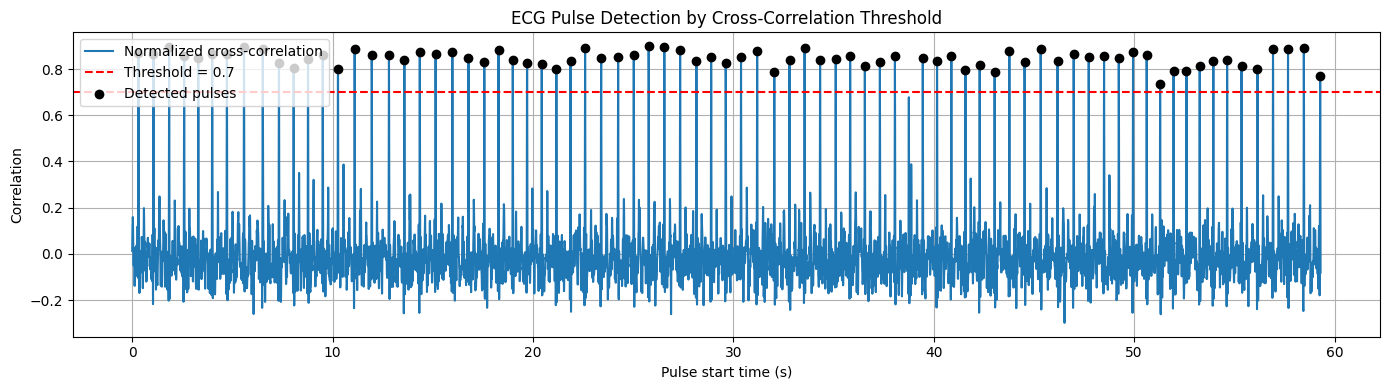

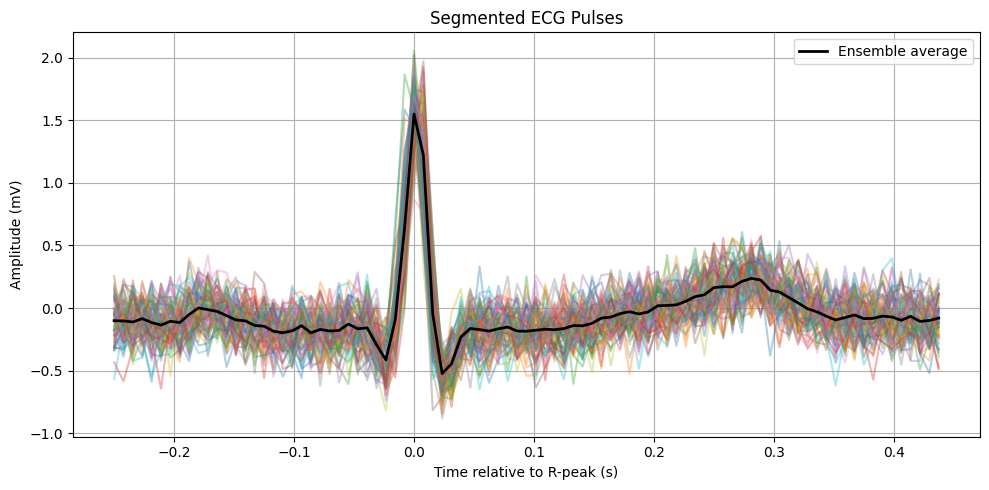

In [77]:

# Segment ECG pulses using a normalized cross-correlation threshold
xcorr_threshold = 0.7

# Detect correlation peaks above the threshold
minimum_pulse_distance = int(
    0.4 * ecg_rec_sampling_frequency
)

pulse_starts, peak_properties = find_peaks(
    normalised_xcorr,
    height=xcorr_threshold,
    distance=minimum_pulse_distance
)

# Keep only complete template-sized segments
pulse_starts = pulse_starts[
    pulse_starts + template.size <= noisy_ecg.size
]

# Store each detected ECG pulse as a row in a separate matrix
segmented_ecg_pulses = np.array([
    noisy_ecg[start:start + template.size]
    for start in pulse_starts
])

print(f"Correlation threshold: {xcorr_threshold}")
print(f"Detected ECG pulses: {segmented_ecg_pulses.shape[0]}")
print(f"Pulse matrix shape: {segmented_ecg_pulses.shape}")

# Plot detected pulse locations
plt.figure(figsize=(14, 4))
plt.plot(xcorr_time, normalised_xcorr, label="Normalized cross-correlation")
plt.axhline(
    xcorr_threshold,
    color="red",
    linestyle="--",
    label=f"Threshold = {xcorr_threshold}"
)
plt.scatter(
    xcorr_time[pulse_starts],
    normalised_xcorr[pulse_starts],
    color="black",
    zorder=3,
    label="Detected pulses"
)
plt.xlabel("Pulse start time (s)")
plt.ylabel("Correlation")
plt.title("ECG Pulse Detection by Cross-Correlation Threshold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot the segmented pulses
plt.figure(figsize=(10, 5))
for pulse in segmented_ecg_pulses:
    plt.plot(ECG_template_time, pulse, alpha=0.35)

plt.plot(
    ECG_template_time,
    np.mean(segmented_ecg_pulses, axis=0),
    color="black",
    linewidth=2,
    label="Ensemble average"
)
plt.xlabel("Time relative to R-peak (s)")
plt.ylabel(f"Amplitude ({ecg_rec_amplitude_units})")
plt.title("Segmented ECG Pulses")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

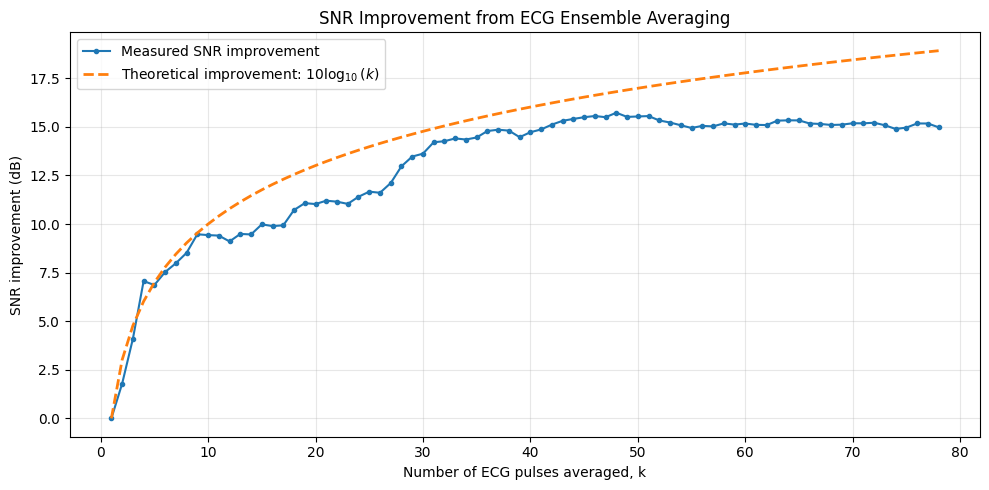

Initial SNR: 5.16 dB
Final SNR: 20.13 dB
Total improvement: 14.98 dB


In [78]:
# Calculate SNR improvement from progressive ECG ensemble averaging

if segmented_ecg_pulses.ndim != 2 or segmented_ecg_pulses.shape[0] == 0:
    raise ValueError("No segmented ECG pulses are available.")

# Match the template length and remove baseline offsets
template = np.asarray(ECG_template, dtype=float).ravel()
pulses = np.asarray(segmented_ecg_pulses, dtype=float)

template = template - np.mean(template)
pulses = pulses - np.mean(pulses, axis=1, keepdims=True)

# Progressive ensemble averages
cumulative_average = np.cumsum(pulses, axis=0)
pulse_counts = np.arange(1, pulses.shape[0] + 1)[:, None]
ensemble_averages = cumulative_average / pulse_counts

# SNR relative to the clean ECG template
signal_power = np.mean(template**2)
mse_values = np.mean(
    (ensemble_averages - template[None, :]) ** 2,
    axis=1
)

snr_values_db = 10 * np.log10(signal_power / mse_values)
snr_improvement_db = snr_values_db - snr_values_db[0]

# Theoretical improvement for independent white noise
theoretical_improvement_db = 10 * np.log10(np.arange(1, pulses.shape[0] + 1))

plt.figure(figsize=(10, 5))
plt.plot(
    np.arange(1, pulses.shape[0] + 1),
    snr_improvement_db,
    "o-",
    markersize=3,
    label="Measured SNR improvement"
)
plt.plot(
    np.arange(1, pulses.shape[0] + 1),
    theoretical_improvement_db,
    "--",
    linewidth=2,
    label=r"Theoretical improvement: $10\log_{10}(k)$"
)

plt.xlabel("Number of ECG pulses averaged, k")
plt.ylabel("SNR improvement (dB)")
plt.title("SNR Improvement from ECG Ensemble Averaging")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Initial SNR: {snr_values_db[0]:.2f} dB")
print(f"Final SNR: {snr_values_db[-1]:.2f} dB")
print(f"Total improvement: {snr_improvement_db[-1]:.2f} dB")

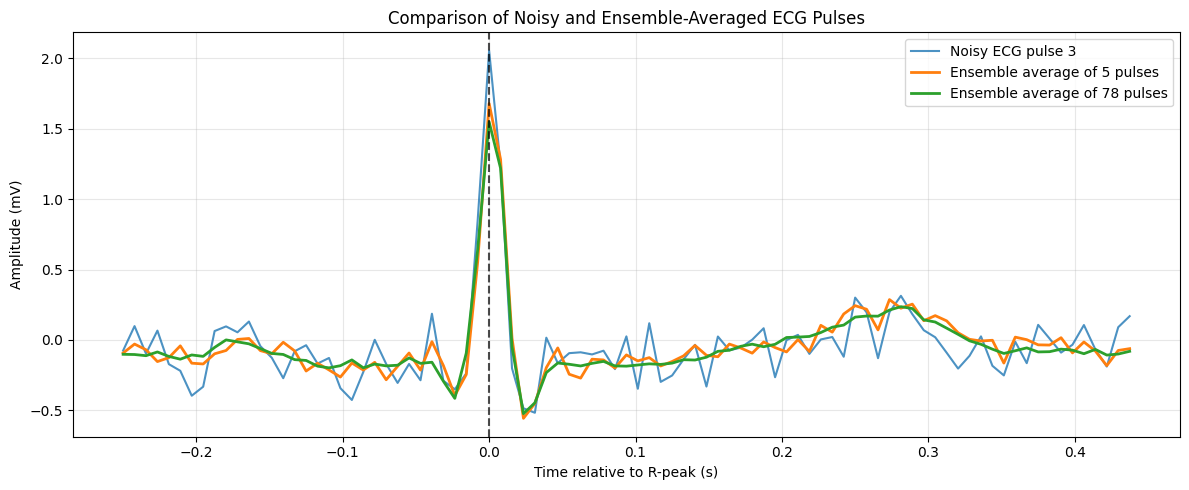

In [79]:
# Select one noisy ECG pulse and two ensemble averages
num_pulses = segmented_ecg_pulses.shape[0]

noisy_pulse_index = min(2, num_pulses - 1)
ensemble_counts = [
    min(5, num_pulses),
    num_pulses
]

selected_noisy_pulse = segmented_ecg_pulses[noisy_pulse_index]

ensemble_average_1 = np.mean(
    segmented_ecg_pulses[:ensemble_counts[0]],
    axis=0
)
ensemble_average_2 = np.mean(
    segmented_ecg_pulses[:ensemble_counts[1]],
    axis=0
)

plt.figure(figsize=(12, 5))

plt.plot(
    ECG_template_time,
    selected_noisy_pulse,
    label=f"Noisy ECG pulse {noisy_pulse_index + 1}",
    alpha=0.8
)
plt.plot(
    ECG_template_time,
    ensemble_average_1,
    linewidth=2,
    label=f"Ensemble average of {ensemble_counts[0]} pulses"
)
plt.plot(
    ECG_template_time,
    ensemble_average_2,
    linewidth=2,
    label=f"Ensemble average of {ensemble_counts[1]} pulses"
)

plt.axvline(0, color="black", linestyle="--", alpha=0.7)
plt.xlabel("Time relative to R-peak (s)")
plt.ylabel(f"Amplitude ({ecg_rec_amplitude_units})")
plt.title("Comparison of Noisy and Ensemble-Averaged ECG Pulses")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Designing FIR Filters Using the Windowing Method

### Characteristics of window functions

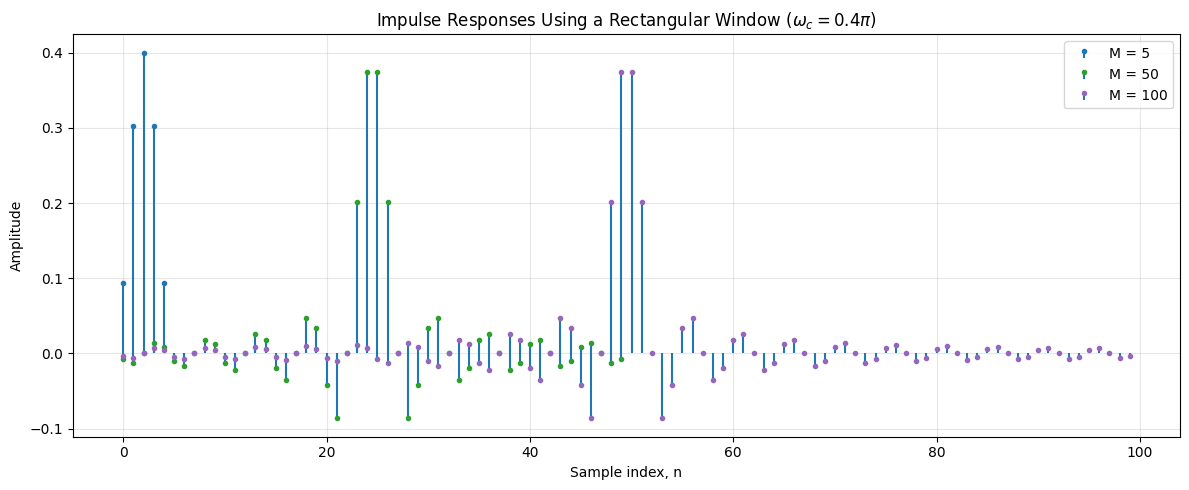

In [5]:
# Impulse responses for rectangular-window FIR filters
wc = 0.4 * np.pi
filter_lengths = [5, 50, 100]

plt.figure(figsize=(12, 5))

for M in filter_lengths:
    n = np.arange(M)
    centre = (M - 1) / 2

    # Ideal low-pass impulse response
    h_ideal = (wc / np.pi) * np.sinc(
        (wc / np.pi) * (n - centre)
    )

    # Rectangular window
    h = h_ideal

    plt.stem(
        n,
        h,
        linefmt="-",
        markerfmt=".",
        basefmt=" ",
        label=f"M = {M}"
    )

plt.xlabel("Sample index, n")
plt.ylabel("Amplitude")
plt.title(r"Impulse Responses Using a Rectangular Window ($\omega_c=0.4\pi$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

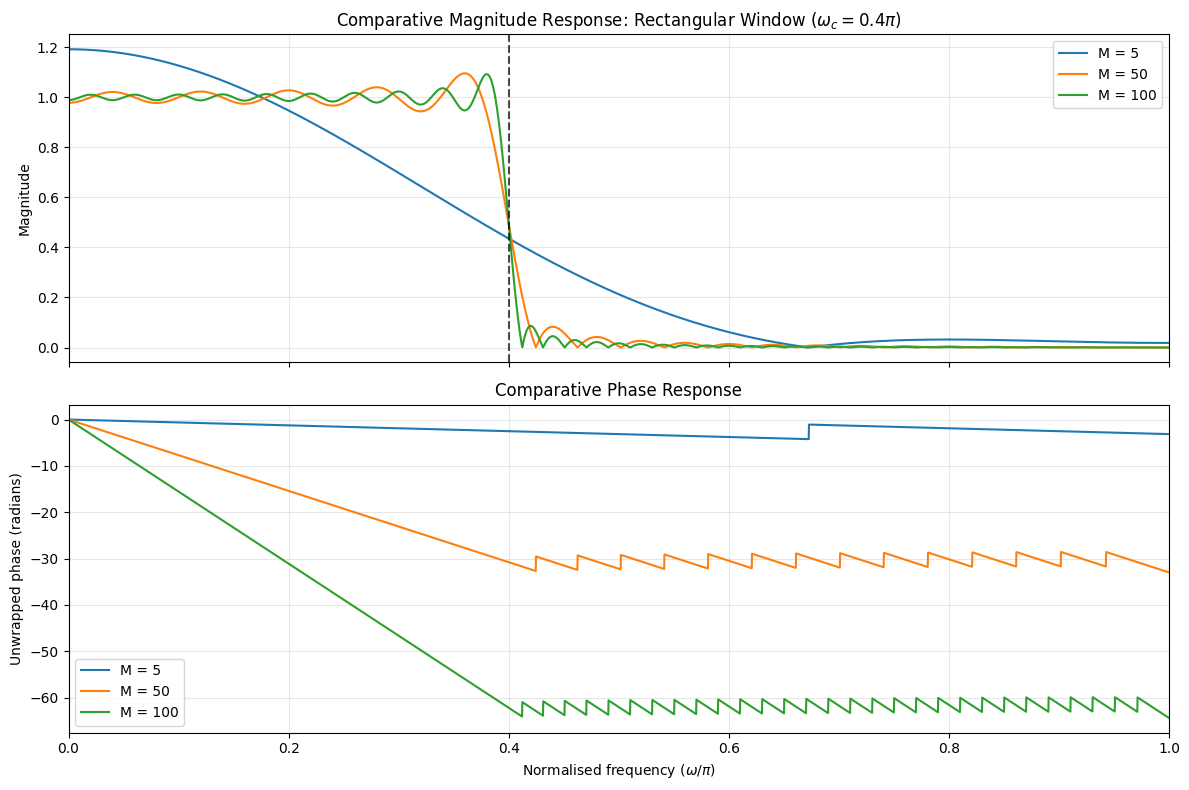

In [7]:
# Comparative responses of rectangular-window lowpass FIR filters
# with cutoff frequency wc = 0.4*pi


wc = 0.4 * np.pi
filter_lengths = [5, 50, 100]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for M in filter_lengths:
    n = np.arange(M)
    centre = (M - 1) / 2

    # Ideal lowpass impulse response
    h_ideal = (wc / np.pi) * np.sinc((wc / np.pi) * (n - centre))

    # Rectangular window
    h = h_ideal * np.ones(M)

    frequency, response = freqz(h, worN=4096)

    magnitude = np.abs(response)
    phase = np.unwrap(np.angle(response))

    axes[0].plot(
        frequency / np.pi,
        magnitude,
        label=f"M = {M}"
    )
    axes[1].plot(
        frequency / np.pi,
        phase,
        label=f"M = {M}"
    )

axes[0].axvline(0.4, color="black", linestyle="--", alpha=0.7)
axes[0].set_ylabel("Magnitude")
axes[0].set_title(
    r"Comparative Magnitude Response: Rectangular Window "
    r"($\omega_c = 0.4\pi$)"
)
axes[0].set_xlim(0, 1)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_xlabel(r"Normalised frequency ($\omega/\pi$)")
axes[1].set_ylabel("Unwrapped phase (radians)")
axes[1].set_title("Comparative Phase Response")
axes[1].set_xlim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

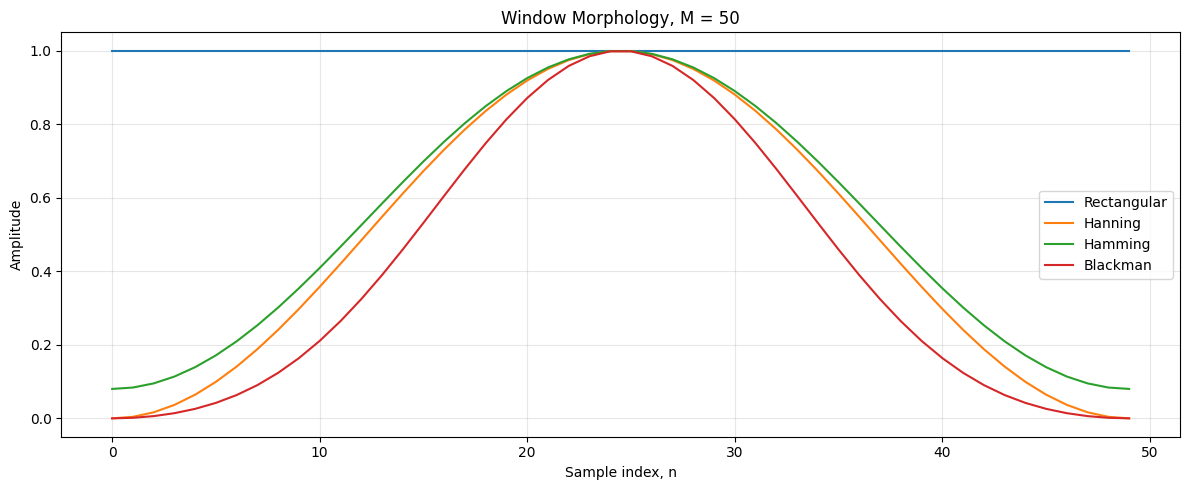

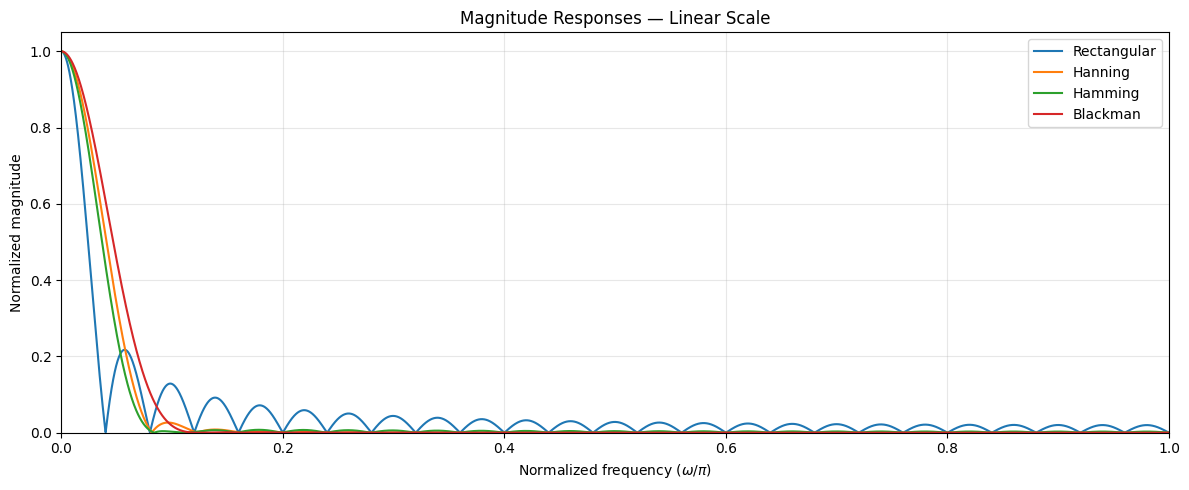

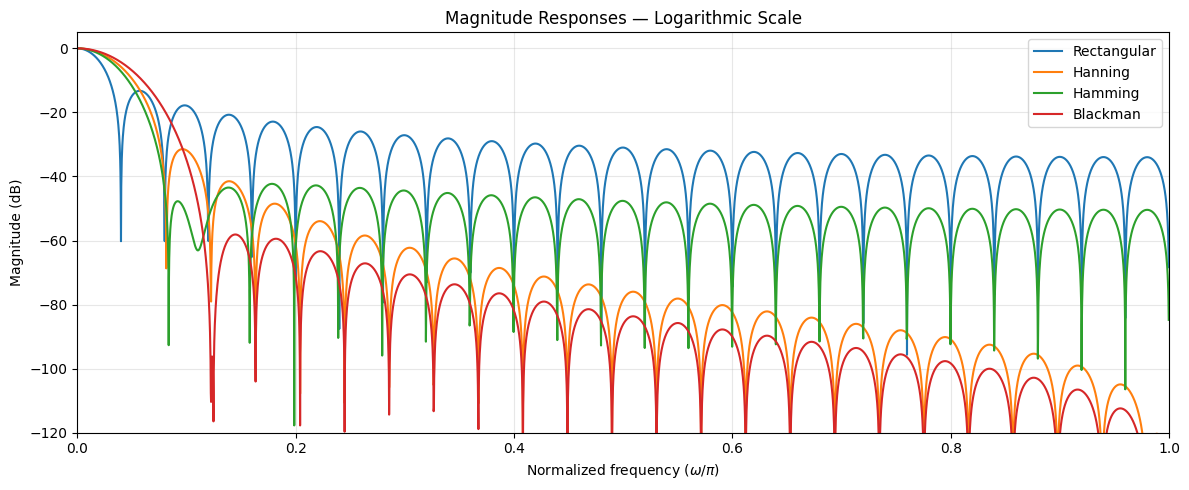

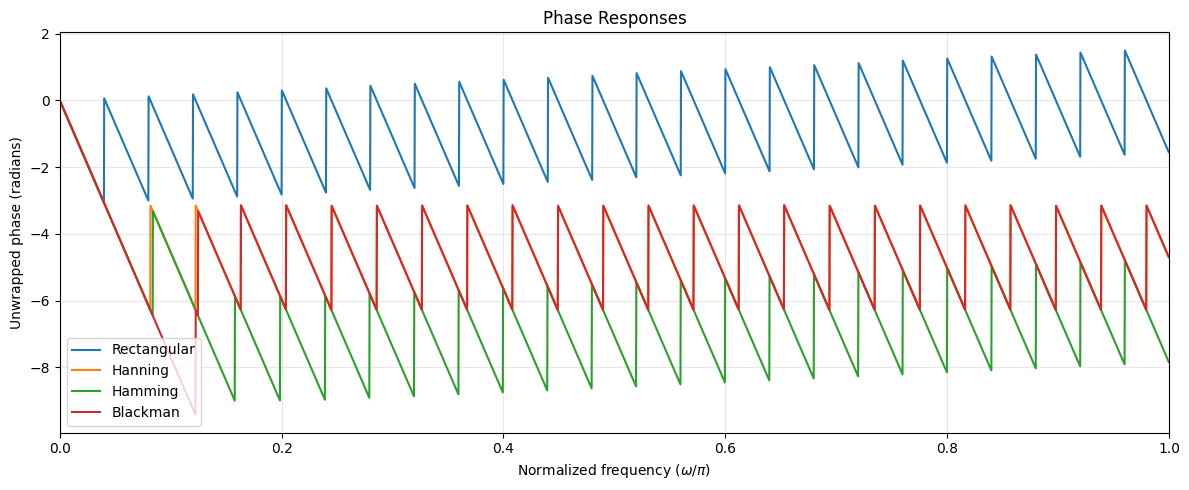

In [8]:
from scipy.signal import freqz

# Comparative characteristics of length-50 window functions


M = 50
n = np.arange(M)

windows_50 = {
    "Rectangular": np.ones(M),
    "Hanning": np.hanning(M),
    "Hamming": np.hamming(M),
    "Blackman": np.blackman(M),
}

# Frequency responses
frequency_responses = {}

for name, window_values in windows_50.items():
    frequency, response = freqz(window_values, worN=4096)
    magnitude = np.abs(response)
    magnitude_normalized = magnitude / np.max(magnitude)
    magnitude_db = 20 * np.log10(
        np.maximum(magnitude_normalized, np.finfo(float).eps)
    )
    phase = np.unwrap(np.angle(response))

    frequency_responses[name] = {
        "window": window_values,
        "magnitude": magnitude_normalized,
        "magnitude_db": magnitude_db,
        "phase": phase,
    }

# 1. Window morphology
plt.figure(figsize=(12, 5))

for name, data in frequency_responses.items():
    plt.plot(n, data["window"], label=name)

plt.xlabel("Sample index, n")
plt.ylabel("Amplitude")
plt.title(f"Window Morphology, M = {M}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Magnitude response with linear scale
plt.figure(figsize=(12, 5))

for name, data in frequency_responses.items():
    plt.plot(
        frequency / np.pi,
        data["magnitude"],
        label=name
    )

plt.xlabel(r"Normalized frequency ($\omega/\pi$)")
plt.ylabel("Normalized magnitude")
plt.title("Magnitude Responses — Linear Scale")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 3. Magnitude response with logarithmic scale
plt.figure(figsize=(12, 5))

for name, data in frequency_responses.items():
    plt.plot(
        frequency / np.pi,
        data["magnitude_db"],
        label=name
    )

plt.xlabel(r"Normalized frequency ($\omega/\pi$)")
plt.ylabel("Magnitude (dB)")
plt.title("Magnitude Responses — Logarithmic Scale")
plt.xlim(0, 1)
plt.ylim(-120, 5)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Phase response
plt.figure(figsize=(12, 5))

for name, data in frequency_responses.items():
    plt.plot(
        frequency / np.pi,
        data["phase"],
        label=name
    )

plt.xlabel(r"Normalized frequency ($\omega/\pi$)")
plt.ylabel("Unwrapped phase (radians)")
plt.title("Phase Responses")
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



Observations:
- The rectangular window has abrupt edges, producing the narrowest main lobe
  but relatively large sidelobes.
- The Hanning window has smoothly tapered edges and lower sidelobes than the
  rectangular window, at the cost of a wider main lobe.
- The Hamming window suppresses sidelobes more strongly than the Hanning window,
  while retaining a slightly narrower main lobe.
- The Blackman window has the smoothest taper and the lowest sidelobes, but also
  the widest main lobe and therefore the poorest frequency resolution.
- All windows are symmetric, so their phase responses are approximately linear,
  corresponding to a group delay of (M - 1) / 2 = 24.5 samples.

### FIR filter design and application using the Kaiser window

Available arrays: ['nECG']


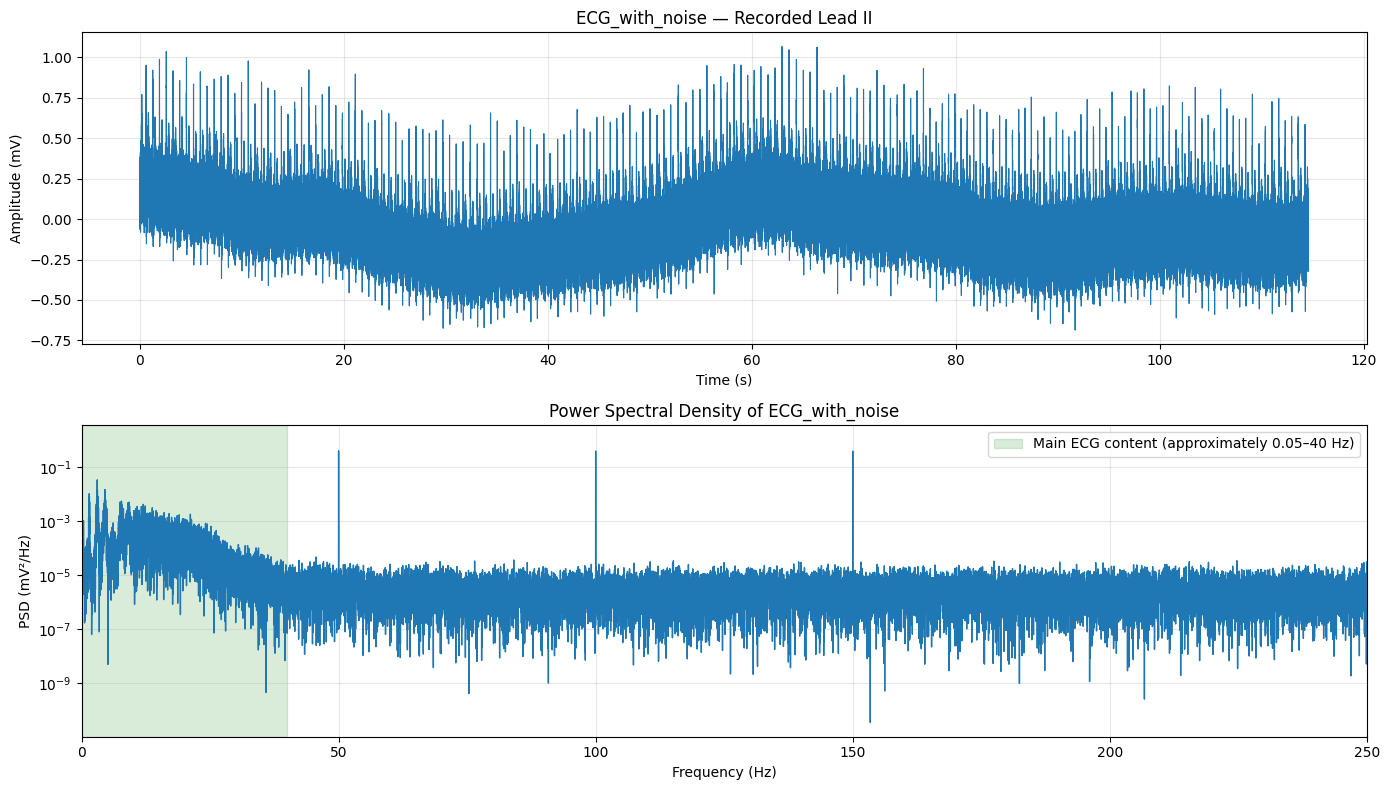

Number of samples: 57299
Recording duration: 114.596 s
Dominant non-zero frequency: 0.02 Hz


In [3]:
from scipy.signal import periodogram

# Load ECG_with_noise recording
ecg_noise_data = np.load("signal_sources/ECG_with_noise.npz")

print("Available arrays:", ecg_noise_data.files)

ecg_with_noise = np.asarray(
    ecg_noise_data[ecg_noise_data.files[0]]
).squeeze()

# Select the recorded Lead II signal if the file contains multiple channels
if ecg_with_noise.ndim > 1:
    ecg_with_noise = ecg_with_noise[:, 0]

ecg_noise_fs = 500  # Hz
ecg_noise_time = np.arange(ecg_with_noise.size) / ecg_noise_fs

# Estimate the power spectral density
ecg_noise_frequencies, ecg_noise_psd = periodogram(
    ecg_with_noise,
    fs=ecg_noise_fs,
    window="hann",
    detrend="constant",
    scaling="density"
)

# Ignore DC when finding the dominant frequency
nonzero = ecg_noise_frequencies > 0
dominant_index = np.argmax(ecg_noise_psd[nonzero])
dominant_frequency = ecg_noise_frequencies[nonzero][dominant_index]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(ecg_noise_time, ecg_with_noise, linewidth=0.8)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].set_title("ECG_with_noise — Recorded Lead II")
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(
    ecg_noise_frequencies,
    ecg_noise_psd,
    linewidth=1.0
)
axes[1].axvspan(0.05, 40, color="green", alpha=0.15,
                label="Main ECG content (approximately 0.05–40 Hz)")
axes[1].set_xlim(0, ecg_noise_fs / 2)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD (mV²/Hz)")
axes[1].set_title("Power Spectral Density of ECG_with_noise")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Number of samples: {ecg_with_noise.size}")
print(f"Recording duration: {ecg_noise_time[-1]:.3f} s")
print(f"Dominant non-zero frequency: {dominant_frequency:.2f} Hz")


In [4]:
# Filter specifications for ECG_with_noise
fs = ecg_noise_fs  # 500 Hz

# (a) Highpass filter:
# Passband begins at 5 Hz; stopband ends at 1 Hz.
hp_fpass = 5       # Hz
hp_fstop = 1       # Hz
hp_delta = 0.001    # maximum amplitude error

# (b) Lowpass filter:
# Passband ends at 125 Hz; stopband begins at 140 Hz.
lp_fpass = 125     # Hz
lp_fstop = 140     # Hz
lp_delta = 0.001    # maximum amplitude error

# (c) Notch filter:
# Remove power-line interference and its harmonics.
notch_fstop1 = 50   # Hz
notch_fstop2 = 100  # Hz
notch_fstop3 = 150  # Hz

print("Highpass:", hp_fpass, hp_fstop, hp_delta)
print("Lowpass:", lp_fpass, lp_fstop, lp_delta)
print("Notch frequencies:", notch_fstop1, notch_fstop2, notch_fstop3)

Highpass: 5 1 0.001
Lowpass: 125 140 0.001
Notch frequencies: 50 100 150


In [5]:
# Kaiser parameters
A = -20 * np.log10(hp_delta)
beta = 0.1102 * (A - 8.7)

# Transition bandwidths
hp_transition_hz = hp_fpass - hp_fstop
lp_transition_hz = lp_fstop - lp_fpass

hp_delta_omega = 2 * np.pi * hp_transition_hz / fs
lp_delta_omega = 2 * np.pi * lp_transition_hz / fs

# Kaiser filter orders
M_hp = int(np.ceil((A - 8) / (2.285 * hp_delta_omega)))
M_lp = int(np.ceil((A - 8) / (2.285 * lp_delta_omega)))

print(f"Attenuation A: {A:.2f} dB")
print(f"Kaiser beta: {beta:.4f}")
print(f"Highpass: Δf = {hp_transition_hz} Hz, M = {M_hp}")
print(f"Lowpass:  Δf = {lp_transition_hz} Hz, M = {M_lp}")

Attenuation A: 60.00 dB
Kaiser beta: 5.6533
Highpass: Δf = 4 Hz, M = 453
Lowpass:  Δf = 15 Hz, M = 121


In [6]:

from scipy.signal import firwin, freqz

# Cutoff frequency = centre of transition band
hp_cutoff = (hp_fstop + hp_fpass) / 2
lp_cutoff = (lp_fpass + lp_fstop) / 2

# Number of coefficients = filter order + 1
numtaps_hp = M_hp
numtaps_lp = M_lp

# High-pass FIR filter
hp_coeff = firwin(
    numtaps_hp,
    hp_cutoff,
    window=('kaiser', beta),
    pass_zero=False,
    fs=fs
)

# Low-pass FIR filter
lp_coeff = firwin(
    numtaps_lp,
    lp_cutoff,
    window=('kaiser', beta),
    pass_zero=True,
    fs=fs
)


w_hp, H_hp = freqz(hp_coeff, worN=8192, fs=fs)
w_lp, H_lp = freqz(lp_coeff, worN=8192, fs=fs)

# Magnitude in dB
mag_hp = 20 * np.log10(np.maximum(np.abs(H_hp), 1e-12))
mag_lp = 20 * np.log10(np.maximum(np.abs(H_lp), 1e-12))

# Unwrapped phase
phase_hp = np.unwrap(np.angle(H_hp))
phase_lp = np.unwrap(np.angle(H_lp))



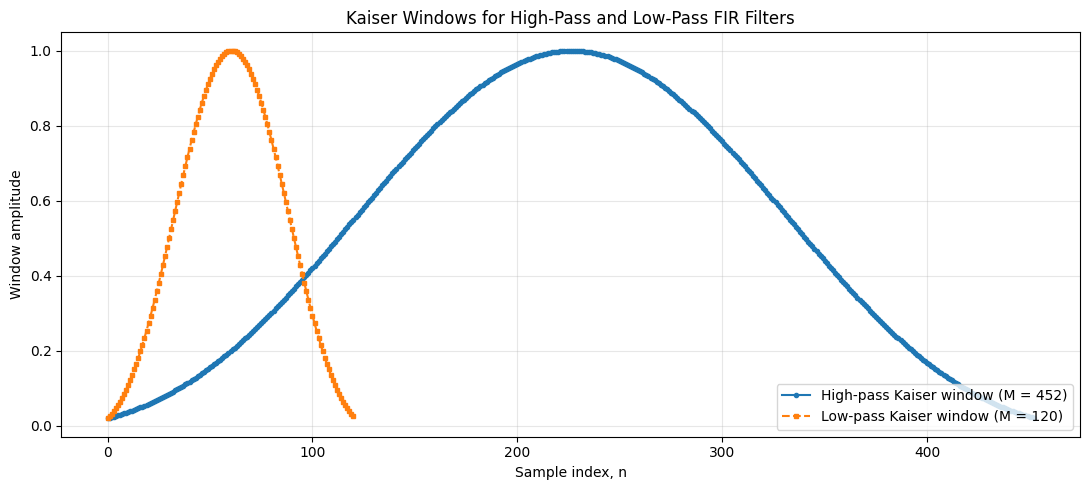

In [7]:
from scipy.signal import get_window

# Generate Kaiser windows
window_hp = get_window(('kaiser', beta), numtaps_hp)
window_lp = get_window(('kaiser', beta), numtaps_lp)

# Plot both windows
plt.figure(figsize=(11, 5))

plt.plot(
    np.arange(numtaps_hp),
    window_hp,
    marker='o',
    markersize=3,
    label=f'High-pass Kaiser window (M = {numtaps_hp - 1})'
)

plt.plot(
    np.arange(numtaps_lp),
    window_lp,
    marker='s',
    markersize=3,
    linestyle='--',
    label=f'Low-pass Kaiser window (M = {numtaps_lp - 1})'
)

plt.title('Kaiser Windows for High-Pass and Low-Pass FIR Filters')
plt.xlabel('Sample index, n')
plt.ylabel('Window amplitude')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

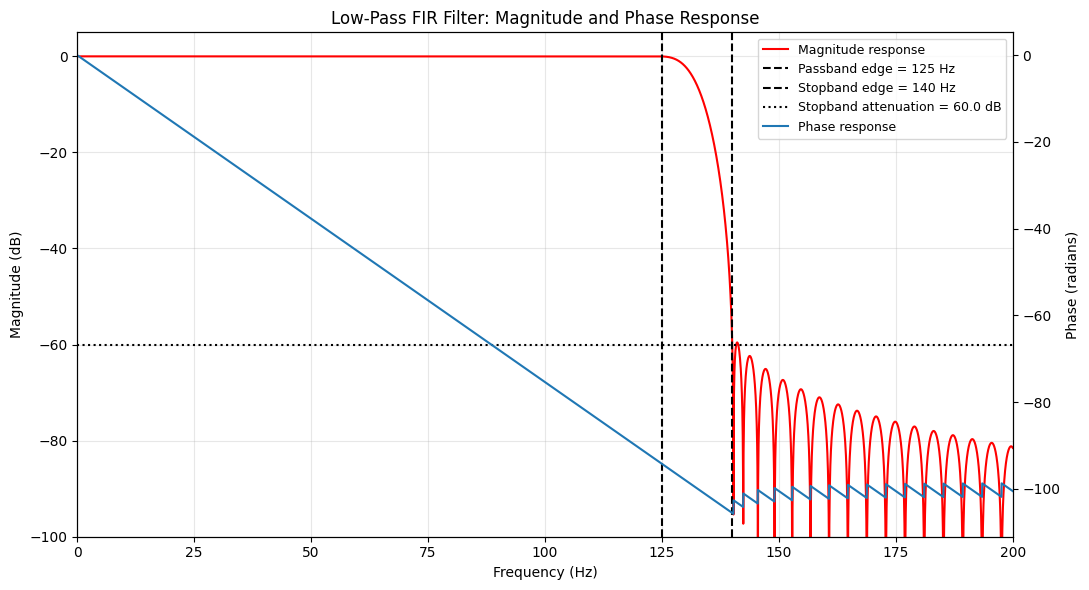

In [8]:


# LOW-PASS FILTER

fig, ax1 = plt.subplots(figsize=(11, 6))

# Magnitude
line1 = ax1.plot(
    w_lp,
    mag_lp,
    color='red',
    label='Magnitude response'
)

ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('Low-Pass FIR Filter: Magnitude and Phase Response')

ax1.set_xlim(0, 200)
ax1.set_ylim(-100, 5)

ax1.grid(True, alpha=0.3)

# Specification lines
ax1.axvline(
    lp_fpass,
    linestyle='--',
    color='black',
    label=f'Passband edge = {lp_fpass} Hz'
)

ax1.axvline(
    lp_fstop,
    linestyle='--',
    color='black',
    label=f'Stopband edge = {lp_fstop} Hz'
)

ax1.axhline(
    -A,
    linestyle=':',
    color='black',
    label=f'Stopband attenuation = {A:.1f} dB'
)


# Phase on second y-axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    w_lp,
    phase_lp,
    label='Phase response'
)

ax2.set_ylabel('Phase (radians)')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right',
    fontsize=9
)

plt.tight_layout()
plt.show()




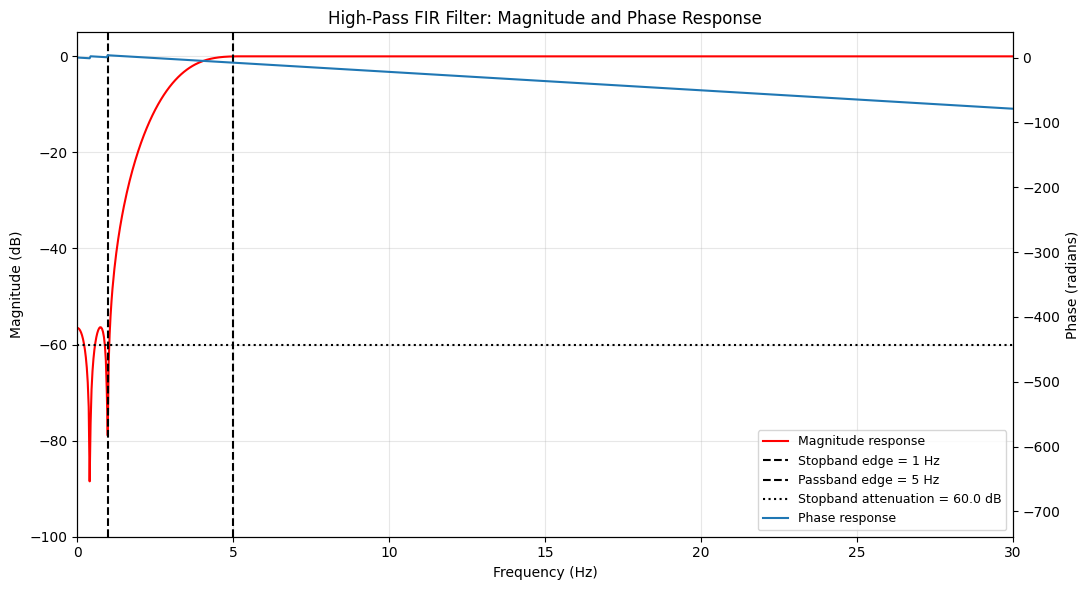

In [9]:
# HIGH-PASS FILTER


fig, ax1 = plt.subplots(figsize=(11, 6))

# Magnitude
line1 = ax1.plot(
    w_hp,
    mag_hp,
    color='red',
    label='Magnitude response'
)

ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('High-Pass FIR Filter: Magnitude and Phase Response')

ax1.set_xlim(0, 30)
ax1.set_ylim(-100, 5)

ax1.grid(True, alpha=0.3)

# Specification lines
ax1.axvline(
    hp_fstop,
    color='black',
    linestyle='--',
    label=f'Stopband edge = {hp_fstop} Hz'
)

ax1.axvline(
    hp_fpass,
    color='black',
    linestyle='--',
    label=f'Passband edge = {hp_fpass} Hz'
)

ax1.axhline(
    -A,
    color='black',
    linestyle=':',

    label=f'Stopband attenuation = {A:.1f} dB'
)


# Phase on second y-axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    w_hp,
    phase_hp,
    label='Phase response'
)

ax2.set_ylabel('Phase (radians)')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='lower right',
    fontsize=9
)

plt.tight_layout()
plt.show()

In [10]:
# Notch centre frequencies
notch_centres = np.array([notch_fstop1, notch_fstop2, notch_fstop3])

# Design choices in Hz
notch_half_width = 1.0    # stopband is centre ± 1 Hz
transition_width = 1.0    # transition band width on each side

# Stopband edges: 49–51, 99–101, 149–151 Hz
stop_lower = notch_centres - notch_half_width
stop_upper = notch_centres + notch_half_width

# Passband edges surrounding every stopband
pass_lower = stop_lower - transition_width
pass_upper = stop_upper + transition_width

# firwin cutoff values: centre of each transition band
notch_cutoffs = np.ravel(
    np.column_stack((
        (pass_lower + stop_lower) / 2,
        (stop_upper + pass_upper) / 2
    ))
)

# Kaiser order calculation, using the narrowest transition bandwidth
notch_delta_omega = 2 * np.pi * transition_width / fs
M_notch = int(np.ceil((A - 8) / (2.285 * notch_delta_omega)))

# Number of taps = order + 1
numtaps_notch = M_notch + 1

# Must be odd because the filter passes DC and Nyquist frequency
if numtaps_notch % 2 == 0:
    numtaps_notch += 1

print(f'Notch filter order = {numtaps_notch - 1}')
print(f'Number of taps = {numtaps_notch}')
print('Cutoff frequencies:', notch_cutoffs)

# Kaiser window
window_notch = get_window(('kaiser', beta), numtaps_notch)

# Multiband band-stop / notch FIR filter
notch_coeff = firwin(
    numtaps_notch,
    notch_cutoffs,
    window=('kaiser', beta),
    pass_zero=True,
    fs=fs
)

# Frequency response
w_notch, H_notch = freqz(notch_coeff, worN=8192, fs=fs)

mag_notch = 20 * np.log10(np.maximum(np.abs(H_notch), 1e-12))
phase_notch = np.unwrap(np.angle(H_notch))



Notch filter order = 1812
Number of taps = 1813
Cutoff frequencies: [ 48.5  51.5  98.5 101.5 148.5 151.5]


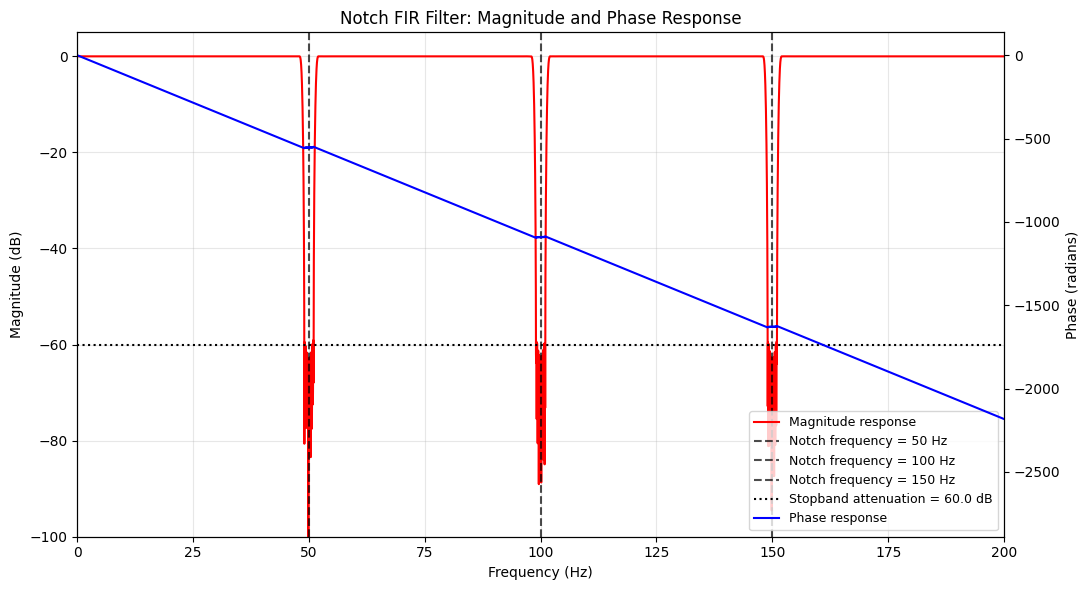

In [11]:
fig, ax1 = plt.subplots(figsize=(11, 6))

# Magnitude
line1 = ax1.plot(
    w_notch,
    mag_notch,
    color='red',
    label='Magnitude response'
)

ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('Notch FIR Filter: Magnitude and Phase Response')
ax1.set_xlim(0, 200)
ax1.set_ylim(-100, 5)
ax1.grid(True, alpha=0.3)

# Notch centre-frequency lines
for frequency in notch_centres:
    ax1.axvline(
        frequency,
        linestyle='--',
        color='black',
        alpha=0.7,
        label=f'Notch frequency = {frequency} Hz'
    )

# Required attenuation line
ax1.axhline(
    -A,
    linestyle=':',
    color='black',
    label=f'Stopband attenuation = {A:.1f} dB'
)

# Phase
ax2 = ax1.twinx()

line2 = ax2.plot(
    w_notch,
    phase_notch,
    color='blue',
    label='Phase response'
)

ax2.set_ylabel('Phase (radians)')

# Remove repeated labels before creating the legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

unique_labels = dict(zip(labels1 + labels2, lines1 + lines2))

ax1.legend(
    unique_labels.values(),
    unique_labels.keys(),
    loc='lower right',
    fontsize=9
)

plt.tight_layout()
plt.show()

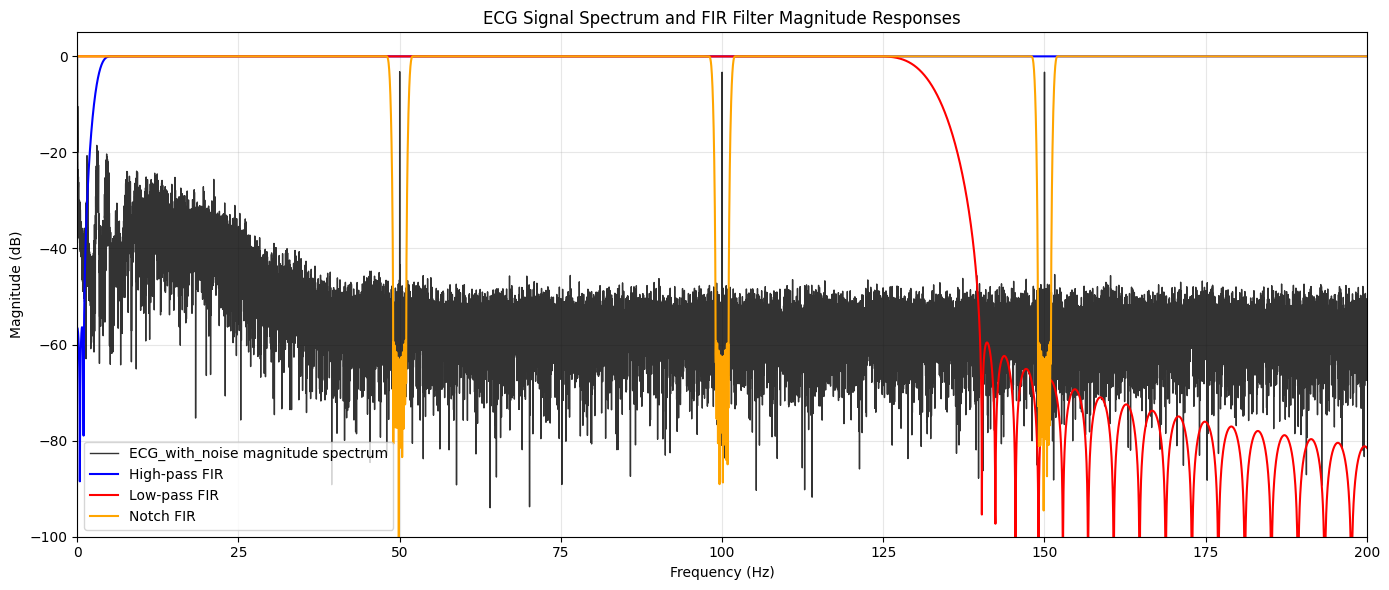

In [12]:
# Frequency-domain magnitude comparison

signal_for_fft = np.asarray(ecg_with_noise, dtype=float).squeeze()
signal_for_fft = signal_for_fft - np.mean(signal_for_fft)

signal_frequencies = np.fft.rfftfreq(
    signal_for_fft.size,
    d=1 / fs
)
signal_spectrum = np.abs(np.fft.rfft(signal_for_fft))
signal_spectrum_db = 20 * np.log10(
    np.maximum(signal_spectrum / np.max(signal_spectrum), 1e-12)
)

plt.figure(figsize=(14, 6))

# ECG signal magnitude spectrum
plt.plot(
    signal_frequencies,
    signal_spectrum_db,
    color="black",
    linewidth=1.0,
    alpha=0.8,
    label="ECG_with_noise magnitude spectrum"
)

# Filter magnitude responses
plt.plot(w_hp, mag_hp, label="High-pass FIR", color ="blue")
plt.plot(w_lp, mag_lp, label="Low-pass FIR", color="red")
plt.plot(w_notch, mag_notch, label="Notch FIR", color="orange")

plt.xlim(0, 200)
plt.ylim(-100, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("ECG Signal Spectrum and FIR Filter Magnitude Responses")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

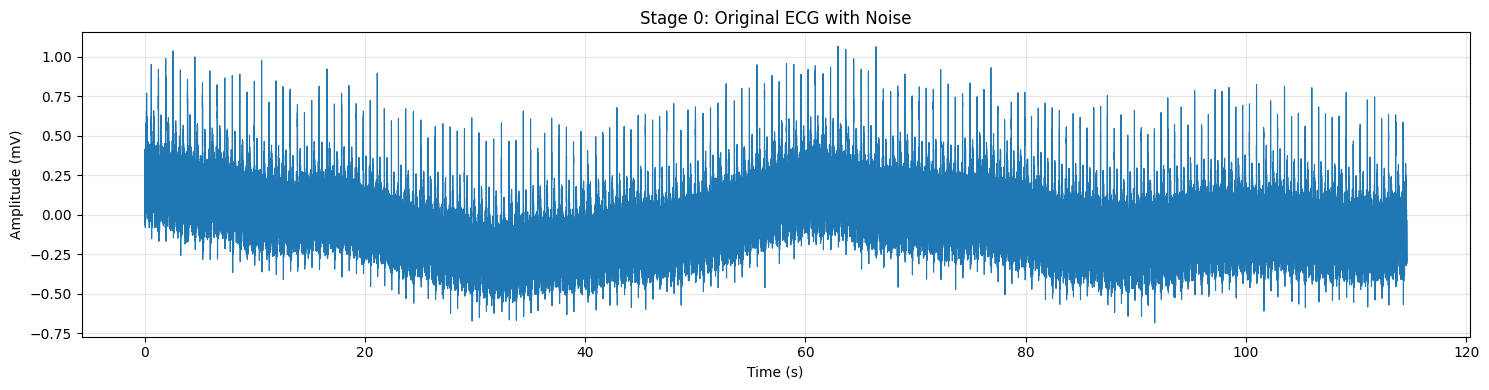

In [14]:
signal = np.asarray(ecg_with_noise, dtype=float)

if signal.ndim > 1:
    signal = signal[:, 0]

time = ecg_noise_time[:len(signal)]

plt.figure(figsize=(15, 4))

plt.plot(
    time,
    signal,
    linewidth=0.8
)

plt.title("Stage 0: Original ECG with Noise")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


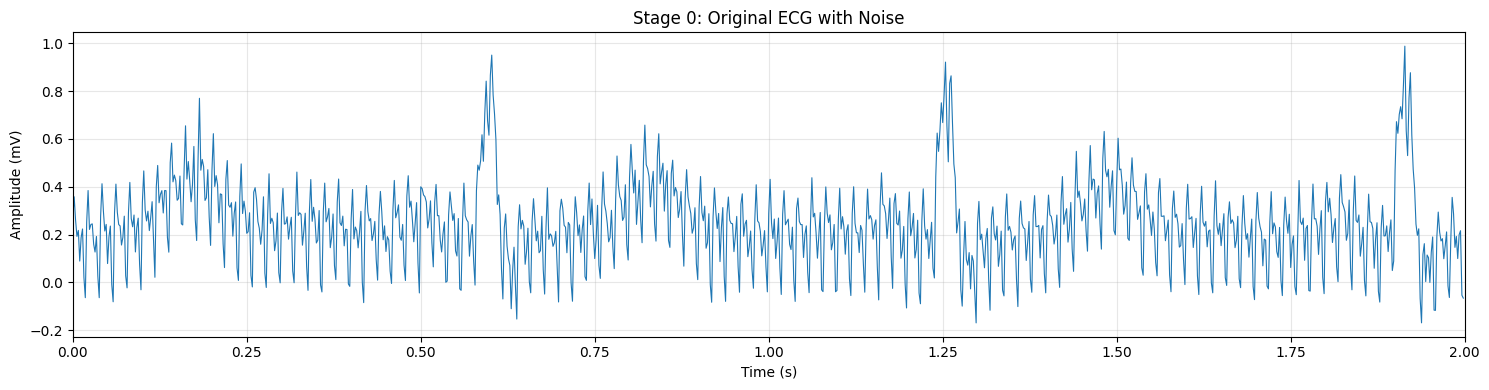

In [15]:
# Select only the first 2 seconds
samples_2s = int(2 * fs)

signal_2s = signal[:samples_2s]
time_2s = ecg_noise_time[:samples_2s]


# Plot original signal
plt.figure(figsize=(15, 4))

plt.plot(
    time_2s,
    signal_2s,
    linewidth=0.8
)

plt.title("Stage 0: Original ECG with Noise")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.xlim(0, 2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


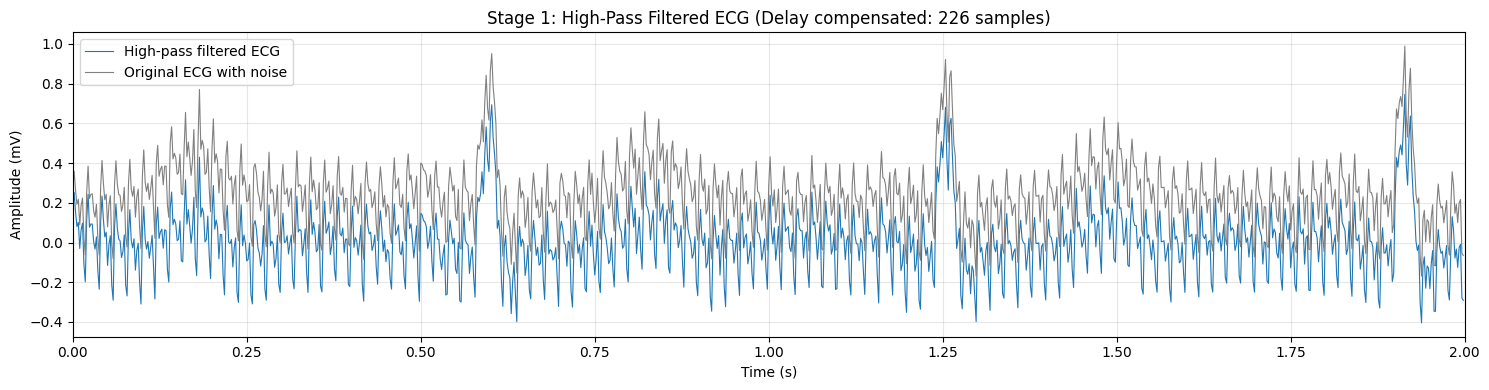

In [16]:


# FIR group delay - high pass filter
delay_hp = (len(hp_coeff) - 1) // 2

# FIR group delay - low pass filter
delay_lp = (len(lp_coeff) - 1) // 2

# FIR group delay - notch filter
delay_notch = (len(notch_coeff) - 1) // 2

hp_filtered = lfilter(
    hp_coeff,
    [1.0],
    signal
)

# Compensate for the FIR delay
hp_compensated = hp_filtered[delay_hp:]

time_hp = time_2s[:len(hp_compensated)]


# Plot high-pass output
plt.figure(figsize=(15, 4))

plt.plot(
    time_hp,
    hp_compensated[:len(time_hp)],
    label="High-pass filtered ECG",
    linewidth=0.8
)

plt.plot(
    time_2s,
    signal_2s,
    label="Original ECG with noise",
    color="gray",
    linewidth=0.8
)


plt.title(
    f"Stage 1: High-Pass Filtered ECG "
    f"(Delay compensated: {delay_hp} samples)"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.xlim(0, 2)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

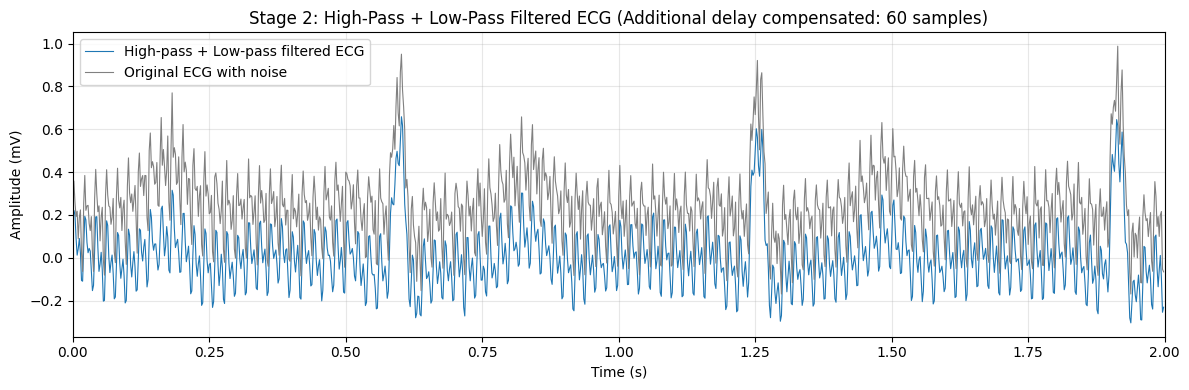

In [17]:

# FIR group delay
delay_lp = (len(lp_coeff) - 1) // 2

lp_filtered = lfilter(
    lp_coeff,
    [1.0],
    hp_compensated
)

# Compensate for the low-pass delay
lp_compensated = lp_filtered[delay_lp:]

time_lp = time_hp[:len(lp_compensated)]


# Plot low-pass output
plt.figure(figsize=(12, 4))

plt.plot(
    time_lp,
    lp_compensated[:len(time_lp)],
    label="High-pass + Low-pass filtered ECG",
    linewidth=0.8
)

plt.plot(
    time_2s,
    signal_2s,
    label="Original ECG with noise",
    color="gray",
    linewidth=0.8
)

plt.title(
    f"Stage 2: High-Pass + Low-Pass Filtered ECG "
    f"(Additional delay compensated: {delay_lp} samples)"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.xlim(0, 2)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

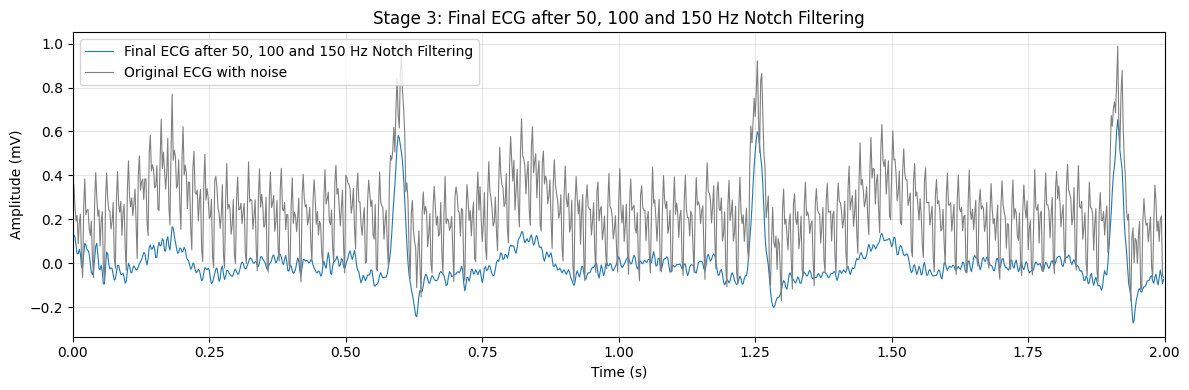

In [18]:
notch_filtered = lp_compensated.copy()

for notch_frequency in (
    notch_fstop1,
    notch_fstop2,
    notch_fstop3
):

    b_notch, a_notch = iirnotch(
        w0=notch_frequency,
        Q=30,
        fs=fs
    )

    notch_filtered = filtfilt(
        b_notch,
        a_notch,
        notch_filtered
    )


time_notch = time_lp[:len(notch_filtered)]


# Plot final output
plt.figure(figsize=(12, 4))

plt.plot(
    time_notch,
    notch_filtered[:len(time_notch)],
    label="Final ECG after 50, 100 and 150 Hz Notch Filtering",
    linewidth=0.8
)

plt.plot(
    time_2s,
    signal_2s,
    label="Original ECG with noise",
    color="gray",
    linewidth=0.8
)

plt.title(
    "Stage 3: Final ECG after 50, 100 and 150 Hz Notch Filtering"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.xlim(0, 2)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [22]:
# Magnitude response of the cascaded HP + LP + notch filters
# and PSD of the final filtered ECG

# FIR filter responses on a common frequency grid
cascade_frequencies, H_hp_cascade = freqz(
    hp_coeff, worN=8192, fs=fs
)
_, H_lp_cascade = freqz(
    lp_coeff, worN=8192, fs=fs
)

# Cascade the three IIR notch filters used in the previous cell.
# filtfilt applies each notch twice, so its magnitude response is squared.
H_notch_cascade = np.ones_like(H_hp_cascade)

for notch_frequency in (
    notch_fstop1,
    notch_fstop2,
    notch_fstop3
):
    b_notch, a_notch = iirnotch(
        w0=notch_frequency,
        Q=30,
        fs=fs
    )

    _, H_iir_notch = freqz(
        b_notch,
        a_notch,
        worN=8192,
        fs=fs
    )

    H_notch_cascade *= np.abs(H_iir_notch) ** 2

# Overall cascaded magnitude response
H_cascade = (
    H_hp_cascade
    * H_lp_cascade
)

magnitude_cascade_db = 20 * np.log10(
    np.maximum(
        np.abs(H_cascade) * H_notch_cascade,
        np.finfo(float).eps
    )
)

# PSD of the final filtered ECG
psd_frequencies, psd_final = periodogram(
    notch_filtered,
    fs=fs,
    window="hann",
    detrend="constant",
    scaling="density"
)



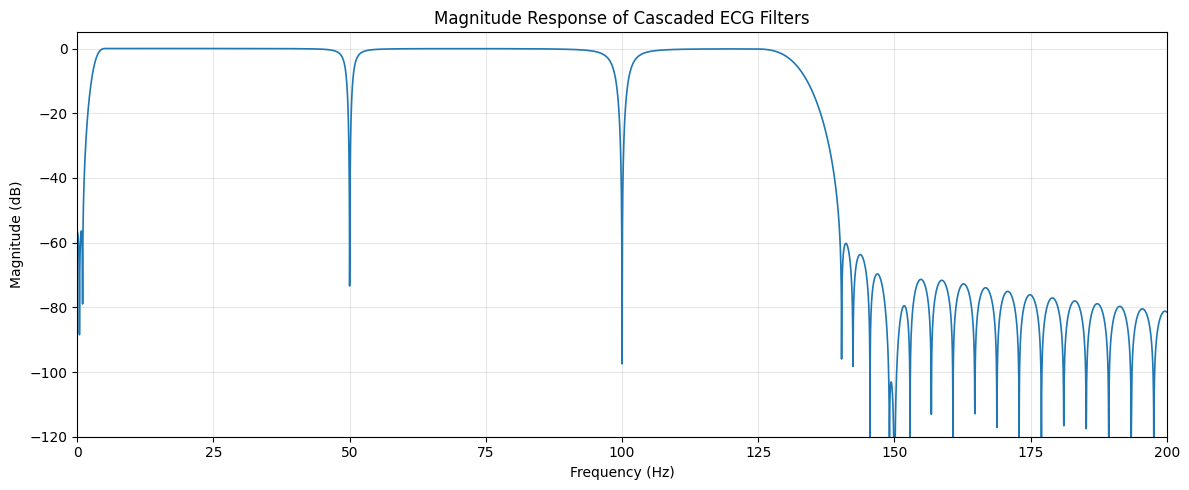

In [20]:
# Magnitude response of the cascaded HP + LP + notch filters

plt.figure(figsize=(12, 5))

plt.plot(
    cascade_frequencies,
    magnitude_cascade_db,
    color="tab:blue",
    linewidth=1.2
)

plt.xlim(0, 200)
plt.ylim(-120, 5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Magnitude Response of Cascaded ECG Filters")
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

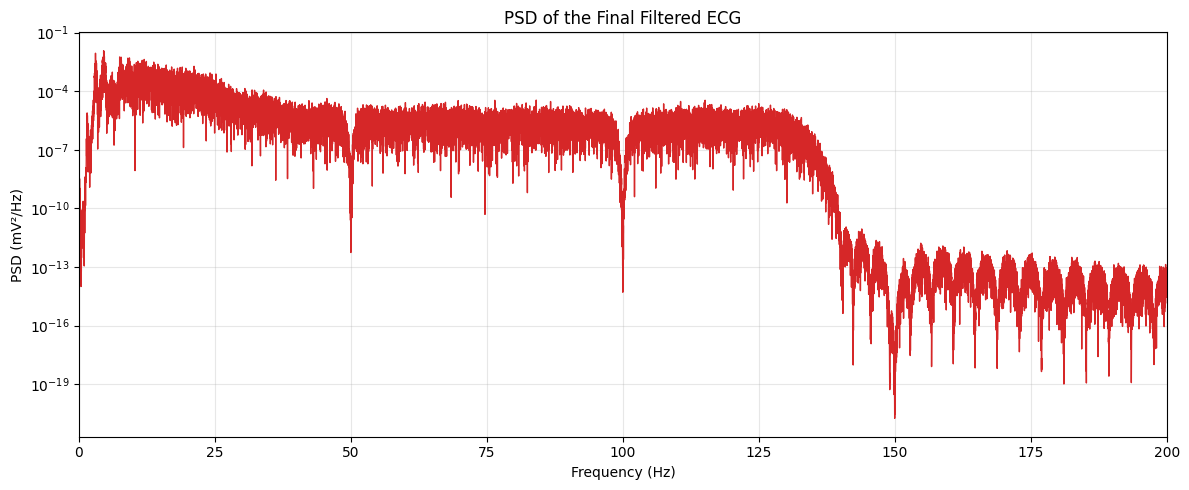

In [21]:
# PSD of the final filtered ECG

plt.figure(figsize=(12, 5))

plt.semilogy(
    psd_frequencies,
    psd_final,
    color="tab:red",
    linewidth=1.0
)

plt.xlim(0, 200)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (mV²/Hz)")
plt.title("PSD of the Final Filtered ECG")
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. IIR Filter Design

In [23]:
from scipy.signal import butter

# Butterworth low-pass filter specifications
butterworth_order = 6
butterworth_cutoff = lp_cutoff  # 132.5 Hz, midpoint of 125–140 Hz

butter_lp_b, butter_lp_a = butter(
    butterworth_order,
    butterworth_cutoff,
    btype="lowpass",
    fs=fs,
    output="ba"
)

print(f"Butterworth order: {butterworth_order}")
print(f"Cutoff frequency: {butterworth_cutoff:.1f} Hz")
print("Numerator coefficients (b):")
print(butter_lp_b)
print("\nDenominator coefficients (a):")
print(butter_lp_a)

Butterworth order: 6
Cutoff frequency: 132.5 Hz
Numerator coefficients (b):
[0.03894426 0.23366555 0.58416389 0.77888518 0.58416389 0.23366555
 0.03894426]

Denominator coefficients (a):
[1.         0.35606143 0.82501592 0.1711713  0.12655638 0.01162226
 0.00200529]


In [ ]:
from scipy.signal import group_delay

# Frequency and phase response
w_butter, h_butter = freqz(
    butter_lp_b,
    butter_lp_a,
    worN=8192,
    fs=fs
)

magnitude_butter_db = 20 * np.log10(
    np.maximum(np.abs(h_butter), np.finfo(float).eps)
)
phase_butter = np.unwrap(np.angle(h_butter))

# Group delay
w_group, delay_butter = group_delay(
    (butter_lp_b, butter_lp_a),
    w=8192,
    fs=fs
)

# Plot all responses in one figure
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(
    w_butter,
    magnitude_butter_db,
    color="tab:blue",
    linewidth=1.5
)
axes[0].set_ylabel("Magnitude (dB)")
axes[0].set_title("Butterworth Low-Pass Filter Response")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    w_butter,
    phase_butter,
    color="tab:orange",
    linewidth=1.5
)
axes[1].set_ylabel("Phase (radians)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(
    w_group,
    delay_butter,
    color="tab:green",
    linewidth=1.5
)
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylabel("Group delay (samples)")
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlim(0, fs / 2)

plt.tight_layout()
plt.show()